# **2. Retrieving data**

### Import library

In [ ]:
from google.colab import drive
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import xgboost as xgb
import lightgbm as lgb
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder,StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve, f1_score
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Load data

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Telecom_customer.csv')

# **3. Data preparation**

### Print 5 baris pertama

In [ ]:
df.head(8)

,rev_Mean,mou_Mean,totmrc_Mean,da_Mean,ovrmou_Mean,ovrrev_Mean,vceovr_Mean,datovr_Mean,roam_Mean,change_mou,...,forgntvl,ethnic,kid0_2,kid3_5,kid6_10,kid11_15,kid16_17,creditcd,eqpdays,Customer_ID
0,23.9975,219.25,22.500,0.2475,0.00,0.0,0.0,0.0,0.0,-157.25,...,0.0,N,U,U,U,U,U,Y,361.0,1000001
1,57.4925,482.75,37.425,0.2475,22.75,9.1,9.1,0.0,0.0,532.25,...,0.0,Z,U,U,U,U,U,Y,240.0,1000002
2,16.9900,10.25,16.990,0.0000,0.00,0.0,0.0,0.0,0.0,-4.25,...,0.0,N,U,Y,U,U,U,Y,1504.0,1000003
3,38.0000,7.50,38.000,0.0000,0.00,0.0,0.0,0.0,0.0,-1.50,...,0.0,U,Y,U,U,U,U,Y,1812.0,1000004
4,55.2300,570.50,71.980,0.0000,0.00,0.0,0.0,0.0,0.0,38.50,...,0.0,I,U,U,U,U,U,Y,434.0,1000005
5,82.2750,1312.25,75.000,1.2375,0.00,0.0,0.0,0.0,0.0,156.75,...,0.0,U,U,U,U,U,U,Y,458.0,1000006
6,17.1450,0.00,16.990,0.0000,0.00,0.0,0.0,0.0,0.0,0.00,...,0.0,N,U,U,U,U,U,Y,852.0,1000007
7,38.0525,682.50,52.490,0.2475,0.00,0.0,0.0,0.0,0.0,147.50,...,1.0,S,U,U,U,U,U,Y,231.0,1000008


### Print 100 baris pertama

In [ ]:
df.loc[:100, ['rev_Mean', 'mou_Mean', 'totmrc_Mean', 'da_Mean', 'ovrmou_Mean', 'ovrrev_Mean', 'vceovr_Mean', 'datovr_Mean', 'roam_Mean', 'change_mou', 'change_rev', 'drop_vce_Mean', 'drop_dat_Mean', 'blck_vce_Mean', 'blck_dat_Mean', 'unan_vce_Mean', 'unan_dat_Mean', 'plcd_vce_Mean', 'plcd_dat_Mean', 'recv_vce_Mean', 'recv_sms_Mean', 'comp_vce_Mean', 'comp_dat_Mean', 'custcare_Mean', 'ccrndmou_Mean', 'cc_mou_Mean', 'inonemin_Mean', 'threeway_Mean', 'mou_cvce_Mean', 'mou_cdat_Mean', 'mou_rvce_Mean', 'owylis_vce_Mean', 'mouowylisv_Mean', 'iwylis_vce_Mean', 'mouiwylisv_Mean', 'peak_vce_Mean', 'peak_dat_Mean', 'mou_peav_Mean', 'mou_pead_Mean', 'opk_vce_Mean', 'opk_dat_Mean', 'mou_opkv_Mean', 'mou_opkd_Mean', 'drop_blk_Mean', 'attempt_Mean', 'complete_Mean', 'callfwdv_Mean', 'callwait_Mean', 'churn', 'months','uniqsubs', 'actvsubs', 'new_cell', 'crclscod', 'asl_flag', 'totcalls', 'totmou', 'totrev', 'adjrev', 'adjmou', 'adjqty', 'avgrev', 'avgmou', 'avgqty', 'avg3mou', 'avg3qty', 'avg3rev', 'avg6mou', 'avg6qty', 'avg6rev', 'prizm_social_one', 'area', 'dualband', 'refurb_new', 'hnd_price', 'phones', 'models', 'hnd_webcap', 'truck', 'rv', 'ownrent', 'lor', 'dwlltype', 'marital', 'adults', 'infobase', 'income', 'numbcars', 'HHstatin', 'dwllsize', 'forgntvl', 'ethnic', 'kid0_2', 'kid3_5', 'kid6_10', 'kid11_15', 'kid16_17', 'creditcd', 'eqpdays', 'Customer_ID']].style.set_properties(**{'border':'solid 1.5px #1c1c1c','background':'rgba(150,214,214,0.4)'})

### Informasi dataset

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 100 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   rev_Mean          99643 non-null   float64
 1   mou_Mean          99643 non-null   float64
 2   totmrc_Mean       99643 non-null   float64
 3   da_Mean           99643 non-null   float64
 4   ovrmou_Mean       99643 non-null   float64
 5   ovrrev_Mean       99643 non-null   float64
 6   vceovr_Mean       99643 non-null   float64
 7   datovr_Mean       99643 non-null   float64
 8   roam_Mean         99643 non-null   float64
 9   change_mou        99109 non-null   float64
 10  change_rev        99109 non-null   float64
 11  drop_vce_Mean     100000 non-null  float64
 12  drop_dat_Mean     100000 non-null  float64
 13  blck_vce_Mean     100000 non-null  float64
 14  blck_dat_Mean     100000 non-null  float64
 15  unan_vce_Mean     100000 non-null  float64
 16  unan_dat_Mean     10

### Melihat deskripsi dataset

In [ ]:
df.describe(include='all')

,rev_Mean,mou_Mean,totmrc_Mean,da_Mean,ovrmou_Mean,ovrrev_Mean,vceovr_Mean,datovr_Mean,roam_Mean,change_mou,...,forgntvl,ethnic,kid0_2,kid3_5,kid6_10,kid11_15,kid16_17,creditcd,eqpdays,Customer_ID
count,99643.000000,99643.000000,99643.000000,99643.000000,99643.000000,99643.000000,99643.000000,99643.000000,99643.000000,99109.000000,...,98268.000000,98268,98268,98268,98268,98268,98268,98268,99999.000000,1.000000e+05
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,17,2,2,2,2,2,2,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,N,U,U,U,U,U,Y,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,33389,94256,93572,90195,89454,88304,67234,NaN,NaN
mean,58.719985,513.559937,46.179136,0.888828,41.072247,13.559560,13.295062,0.261318,1.286405,-13.933818,...,0.057974,NaN,NaN,NaN,NaN,NaN,NaN,NaN,391.932309,1.050000e+06
std,46.291677,525.168140,23.623489,2.177619,97.296150,30.500885,30.056089,3.126531,14.711374,276.087509,...,0.233696,NaN,NaN,NaN,NaN,NaN,NaN,NaN,256.482193,2.886766e+04
min,-6.167500,0.000000,-26.915000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-3875.000000,...,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-5.000000,1.000001e+06
25%,33.260000,150.750000,30.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-87.000000,...,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,212.000000,1.025001e+06
50%,48.195000,355.500000,44.990000,0.247500,2.750000,1.000000,0.682500,0.000000,0.000000,-6.250000,...,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,342.000000,1.050000e+06
75%,70.750000,703.000000,59.990000,0.990000,42.000000,14.437500,14.025000,0.000000,0.235000,63.000000,...,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,530.000000,1.075000e+06


### Drop kolom ID

In [ ]:
df = df.drop('Customer_ID', axis=1)
print("Kolom 'Customer_ID' berhasil dihapus.")
df.info()

Kolom 'Customer_ID' berhasil dihapus.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 99 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   rev_Mean          99643 non-null   float64
 1   mou_Mean          99643 non-null   float64
 2   totmrc_Mean       99643 non-null   float64
 3   da_Mean           99643 non-null   float64
 4   ovrmou_Mean       99643 non-null   float64
 5   ovrrev_Mean       99643 non-null   float64
 6   vceovr_Mean       99643 non-null   float64
 7   datovr_Mean       99643 non-null   float64
 8   roam_Mean         99643 non-null   float64
 9   change_mou        99109 non-null   float64
 10  change_rev        99109 non-null   float64
 11  drop_vce_Mean     100000 non-null  float64
 12  drop_dat_Mean     100000 non-null  float64
 13  blck_vce_Mean     100000 non-null  float64
 14  blck_dat_Mean     100000 non-null  float64
 15  unan_vce_Mean     100000 non-nu

### Melihat banyak missing values pada tiap fitur

In [ ]:
df.isna().sum().to_frame().style.set_properties(**{'border':'solid 1.5px #1c1c1c','background':'rgba(150,214,214,0.4)'})

,0
rev_Mean,357
mou_Mean,357
totmrc_Mean,357
da_Mean,357
ovrmou_Mean,357
ovrrev_Mean,357
vceovr_Mean,357
datovr_Mean,357
roam_Mean,357
change_mou,891


In [ ]:

df.isna().sum().to_frame().style.set_properties(**{'border':'solid 1.5px #1c1c1c','background':'rgba(150,214,214,0.4)'})

,0
rev_Mean,357
mou_Mean,357
totmrc_Mean,357
da_Mean,357
ovrmou_Mean,357
ovrrev_Mean,357
vceovr_Mean,357
datovr_Mean,357
roam_Mean,357
change_mou,891


In [ ]:
columns_to_impute = [
    'rev_Mean', 'mou_Mean', 'totmrc_Mean', 'da_Mean', 'ovrmou_Mean',
    'ovrrev_Mean', 'vceovr_Mean', 'datovr_Mean', 'roam_Mean'
]

# Initialize SimpleImputer with median strategy
imputer = SimpleImputer(strategy='median')

# Apply imputation to the specified columns
df[columns_to_impute] = imputer.fit_transform(df[columns_to_impute])

# Verify that there are no more missing values in these columns
print(df[columns_to_impute].isnull().sum())

rev_Mean       0
mou_Mean       0
totmrc_Mean    0
da_Mean        0
ovrmou_Mean    0
ovrrev_Mean    0
vceovr_Mean    0
datovr_Mean    0
roam_Mean      0
dtype: int64


In [ ]:
columns_to_impute_2 = ['change_mou', 'change_rev']

imputer_2 = SimpleImputer(strategy='median')
df[columns_to_impute_2] = imputer_2.fit_transform(df[columns_to_impute_2])

print(df[columns_to_impute_2].isnull().sum())

change_mou    0
change_rev    0
dtype: int64


In [ ]:
columns_to_impute_3 = ['avg6mou', 'avg6qty', 'avg6rev']

imputer_3 = SimpleImputer(strategy='median')
df[columns_to_impute_3] = imputer_3.fit_transform(df[columns_to_impute_3])

print(df[columns_to_impute_3].isnull().sum())

avg6mou    0
avg6qty    0
avg6rev    0
dtype: int64


In [ ]:
imputer_hnd_price = SimpleImputer(strategy='median')
df['hnd_price'] = imputer_hnd_price.fit_transform(df[['hnd_price']])
print(df['hnd_price'].isnull().sum())

0


In [ ]:
# List kolom untuk diimputasi
cols_to_impute_categorical = ['truck', 'rv', 'forgntvl', 'ethnic', 'kid0_2', 'kid3_5', 'kid6_10', 'kid11_15', 'kid16_17', 'creditcd', 'marital', 'dualband', 'refurb_new', 'area']
cols_to_impute_numerical = ['phones', 'models', 'eqpdays']

# Imputasi kolom kategorikal dengan "Unknown"
for col in cols_to_impute_categorical:
    if col in df.columns:
        df[col].fillna('Unknown', inplace=True)
        print(f"Kolom '{col}' (kategorikal) diimputasi dengan 'Unknown'.")
    else:
        print(f"Peringatan: Kolom '{col}' tidak ditemukan dalam DataFrame.")

# Imputasi kolom numerikal dengan median
for col in cols_to_impute_numerical:
    if col in df.columns:
        # Pastikan kolom adalah numerik sebelum menghitung median
        if pd.api.types.is_numeric_dtype(df[col]):
            median_val = df[col].median()
            df[col].fillna(median_val, inplace=True)
            print(f"Kolom '{col}' (numerikal) diimputasi dengan median: {median_val}.")
        else:
            print(f"Peringatan: Kolom '{col}' seharusnya numerikal tetapi memiliki tipe data {df[col].dtype}. Tidak diimputasi dengan median.")
    else:
        print(f"Peringatan: Kolom '{col}' tidak ditemukan dalam DataFrame.")

print("\nVerifikasi missing values setelah imputasi:")
print(df[cols_to_impute_categorical + cols_to_impute_numerical].isnull().sum())


Kolom 'truck' (kategorikal) diimputasi dengan 'Unknown'.
Kolom 'rv' (kategorikal) diimputasi dengan 'Unknown'.
Kolom 'forgntvl' (kategorikal) diimputasi dengan 'Unknown'.
Kolom 'ethnic' (kategorikal) diimputasi dengan 'Unknown'.
Kolom 'kid0_2' (kategorikal) diimputasi dengan 'Unknown'.
Kolom 'kid3_5' (kategorikal) diimputasi dengan 'Unknown'.
Kolom 'kid6_10' (kategorikal) diimputasi dengan 'Unknown'.
Kolom 'kid11_15' (kategorikal) diimputasi dengan 'Unknown'.
Kolom 'kid16_17' (kategorikal) diimputasi dengan 'Unknown'.
Kolom 'creditcd' (kategorikal) diimputasi dengan 'Unknown'.
Kolom 'marital' (kategorikal) diimputasi dengan 'Unknown'.
Kolom 'dualband' (kategorikal) diimputasi dengan 'Unknown'.
Kolom 'refurb_new' (kategorikal) diimputasi dengan 'Unknown'.
Kolom 'area' (kategorikal) diimputasi dengan 'Unknown'.
Kolom 'phones' (numerikal) diimputasi dengan median: 1.0.
Kolom 'models' (numerikal) diimputasi dengan median: 1.0.
Kolom 'eqpdays' (numerikal) diimputasi dengan median: 342.0.

V

/tmp/ipykernel_2787/1232708771.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna('Unknown', inplace=True)
/tmp/ipykernel_2787/1232708771.py:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Unknown' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df[col].fillna('Unknown', inplace=True)
/tmp/ipykernel_2787/1232708771.py:19: FutureWarning: A value is trying to be set on a copy of a DataFra

In [ ]:
columns_to_drop_new = [
    'numbcars', 'ownrent', 'dwlltype', 'dwllsize', 'HHstatin', 'lor',
    'adults', 'income', 'infobase', 'hnd_webcap', 'prizm_social_one'
]
df = df.drop(columns=columns_to_drop_new, errors='ignore')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 88 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   rev_Mean         100000 non-null  float64
 1   mou_Mean         100000 non-null  float64
 2   totmrc_Mean      100000 non-null  float64
 3   da_Mean          100000 non-null  float64
 4   ovrmou_Mean      100000 non-null  float64
 5   ovrrev_Mean      100000 non-null  float64
 6   vceovr_Mean      100000 non-null  float64
 7   datovr_Mean      100000 non-null  float64
 8   roam_Mean        100000 non-null  float64
 9   change_mou       100000 non-null  float64
 10  change_rev       100000 non-null  float64
 11  drop_vce_Mean    100000 non-null  float64
 12  drop_dat_Mean    100000 non-null  float64
 13  blck_vce_Mean    100000 non-null  float64
 14  blck_dat_Mean    100000 non-null  float64
 15  unan_vce_Mean    100000 non-null  float64
 16  unan_dat_Mean    100000 non-null  float

### Melihat data duplicate

In [ ]:
duplicates = df.duplicated()

print("Baris duplikat:")
print(df[duplicates])

Baris duplikat:
Empty DataFrame
Columns: [rev_Mean, mou_Mean, totmrc_Mean, da_Mean, ovrmou_Mean, ovrrev_Mean, vceovr_Mean, datovr_Mean, roam_Mean, change_mou, change_rev, drop_vce_Mean, drop_dat_Mean, blck_vce_Mean, blck_dat_Mean, unan_vce_Mean, unan_dat_Mean, plcd_vce_Mean, plcd_dat_Mean, recv_vce_Mean, recv_sms_Mean, comp_vce_Mean, comp_dat_Mean, custcare_Mean, ccrndmou_Mean, cc_mou_Mean, inonemin_Mean, threeway_Mean, mou_cvce_Mean, mou_cdat_Mean, mou_rvce_Mean, owylis_vce_Mean, mouowylisv_Mean, iwylis_vce_Mean, mouiwylisv_Mean, peak_vce_Mean, peak_dat_Mean, mou_peav_Mean, mou_pead_Mean, opk_vce_Mean, opk_dat_Mean, mou_opkv_Mean, mou_opkd_Mean, drop_blk_Mean, attempt_Mean, complete_Mean, callfwdv_Mean, callwait_Mean, churn, months, uniqsubs, actvsubs, new_cell, crclscod, asl_flag, totcalls, totmou, totrev, adjrev, adjmou, adjqty, avgrev, avgmou, avgqty, avg3mou, avg3qty, avg3rev, avg6mou, avg6qty, avg6rev, area, dualband, refurb_new, hnd_price, phones, models, truck, rv, marital, for

### Feature Engineering

In [ ]:
# Rasio engagement
df['completion_rate'] = df['comp_vce_Mean'] / (df['attempt_Mean'] + 1e-5)
df['drop_rate'] = df['drop_vce_Mean'] / (df['plcd_vce_Mean'] + 1e-5)

# Revenue per menit
df['rev_per_mou'] = df['rev_Mean'] / (df['mou_Mean'] + 1e-5)

# Tren (change relatif)
df['rev_change_pct'] = df['change_rev'] / (df['avg3rev'] + 1e-5)
df['mou_change_pct'] = df['change_mou'] / (df['avg3mou'] + 1e-5)

### Memeriksa Outliers

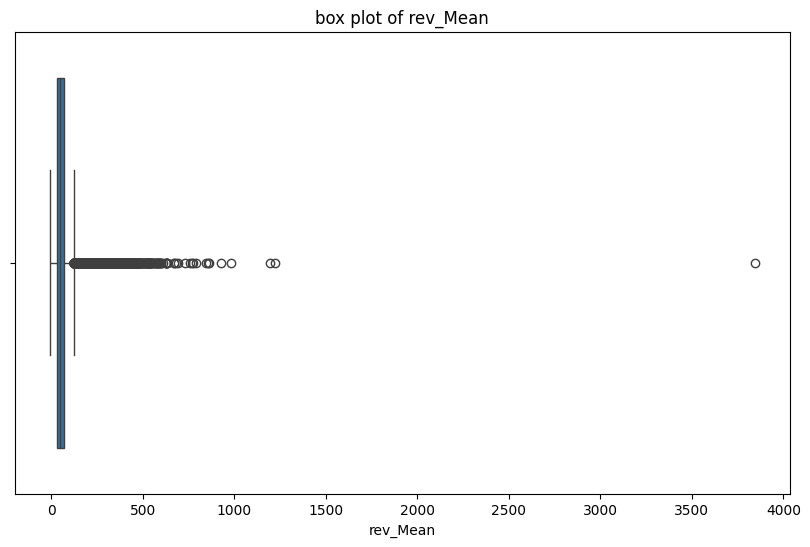

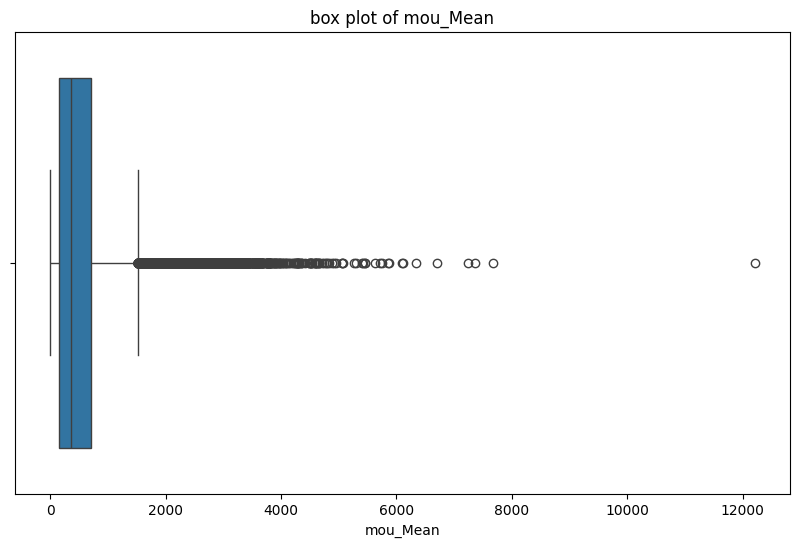

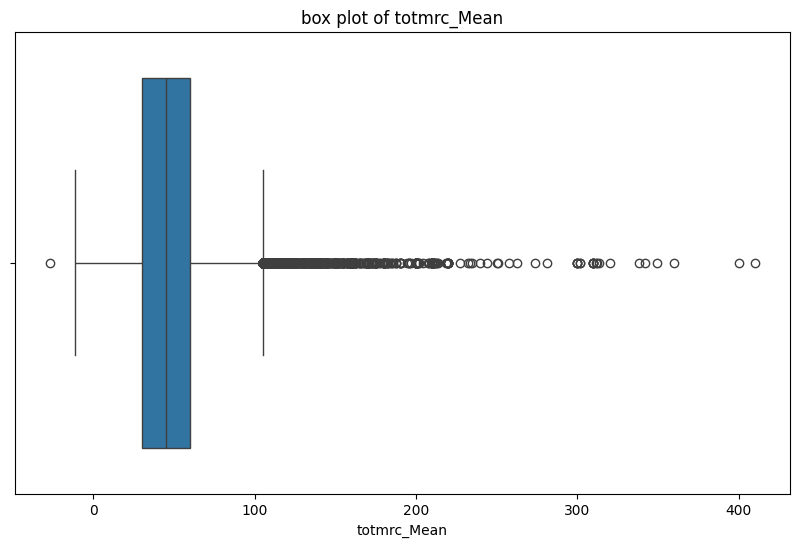

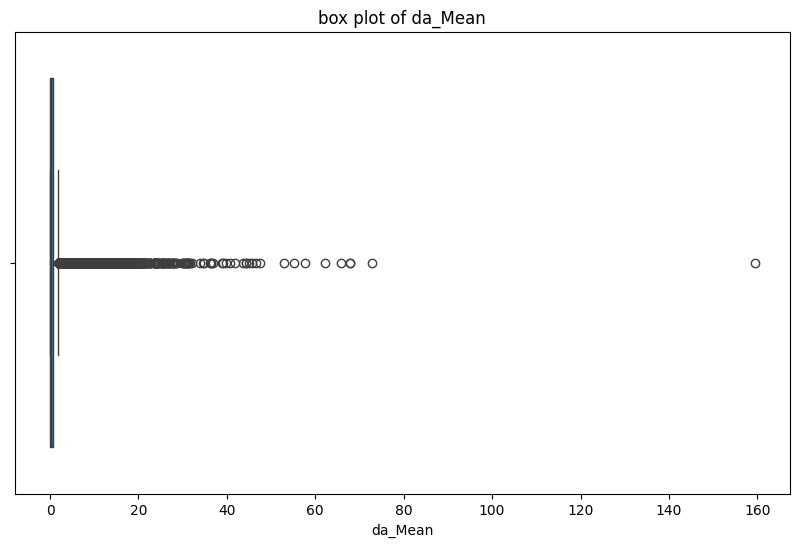

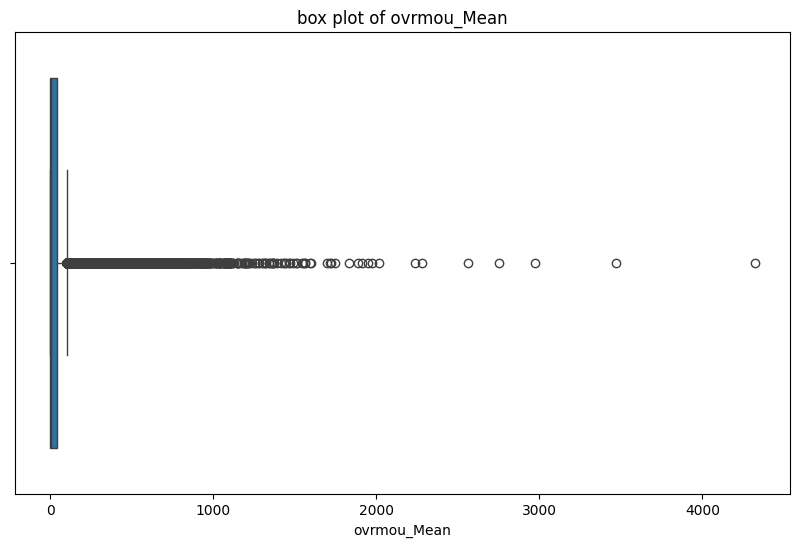

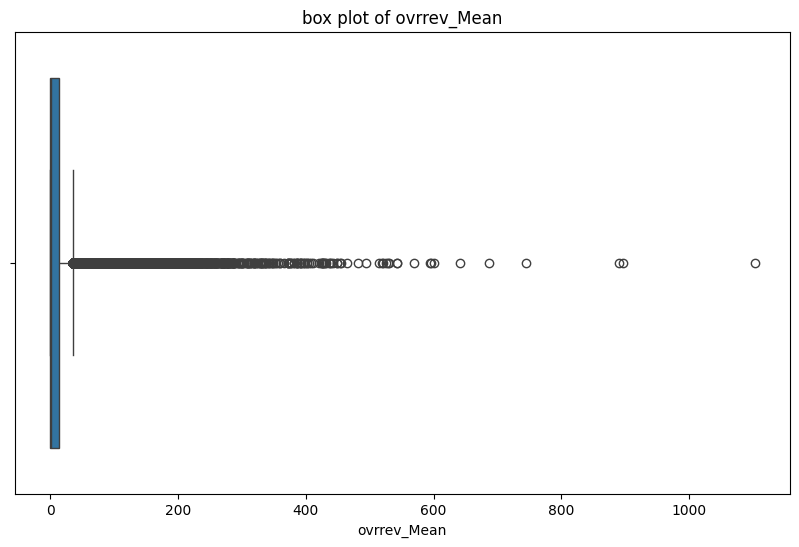

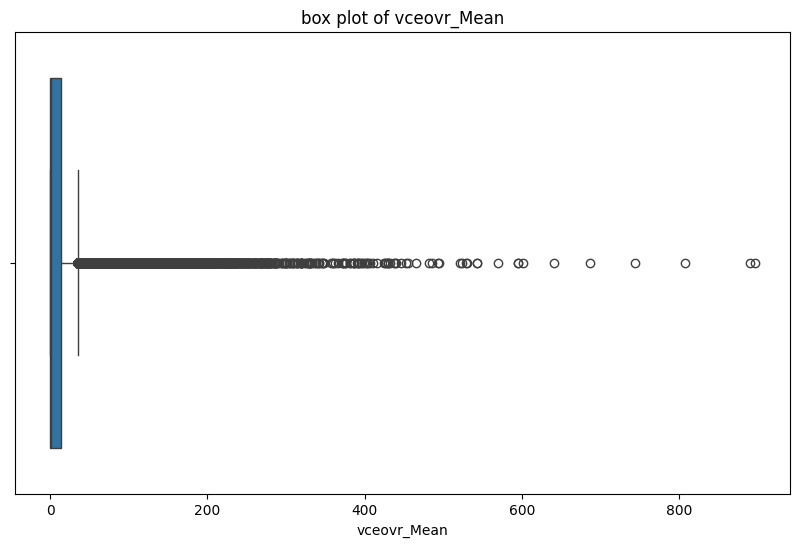

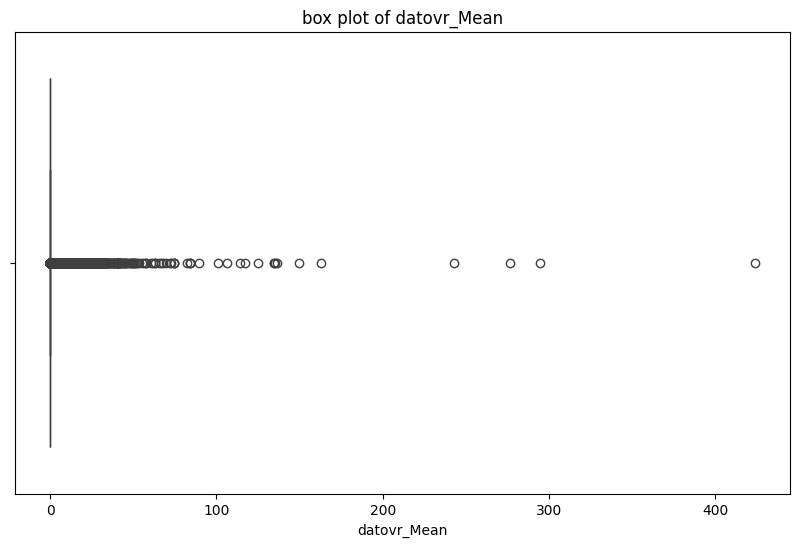

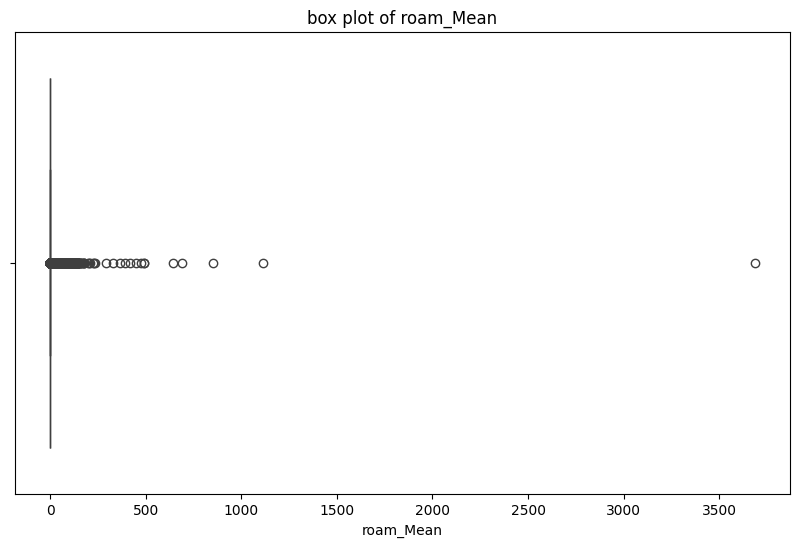

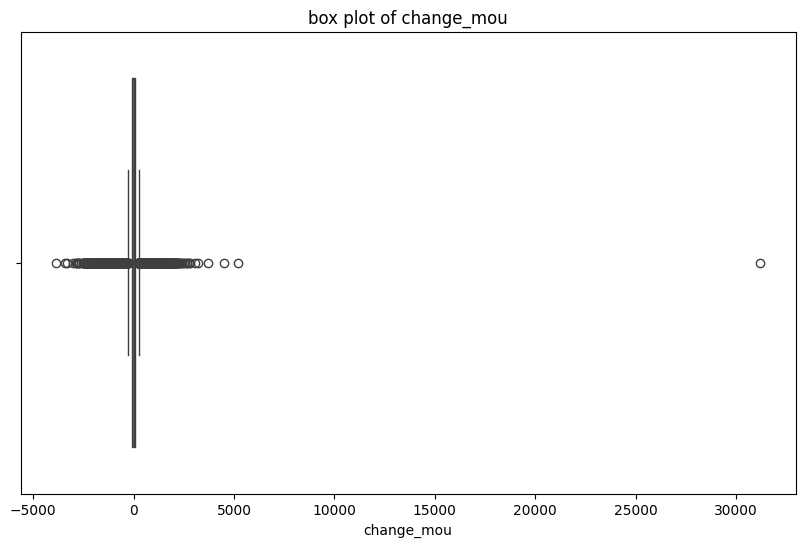

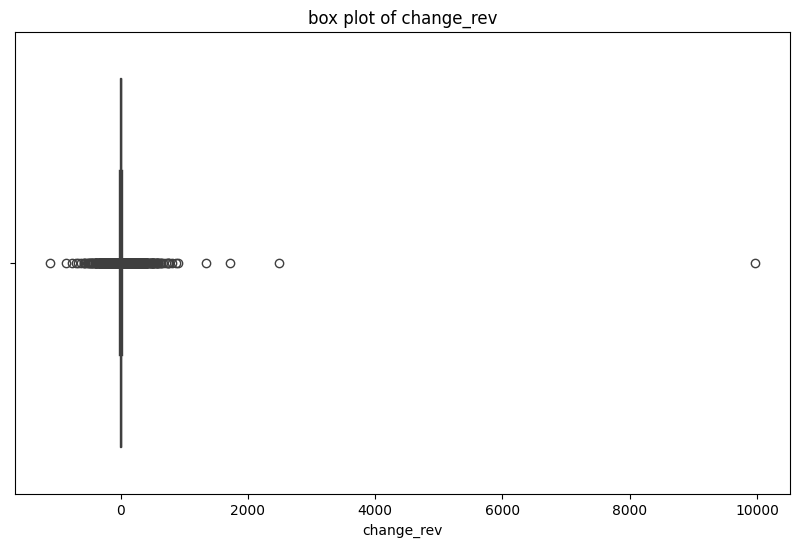

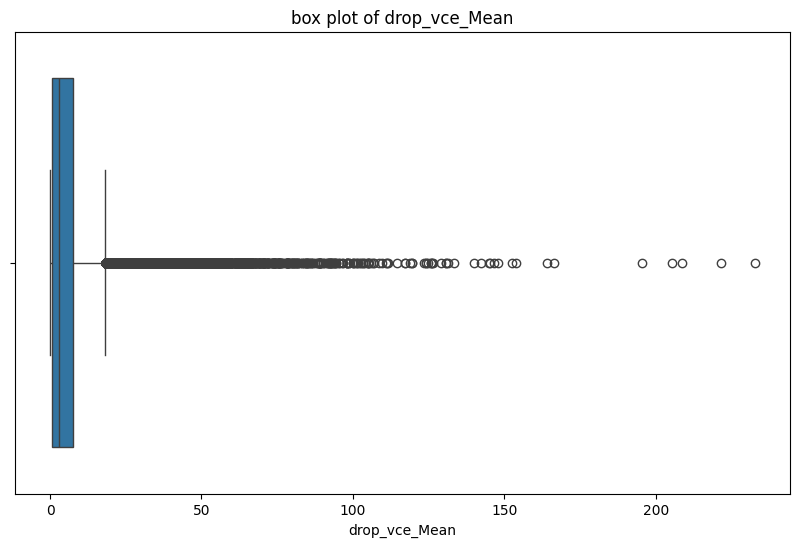

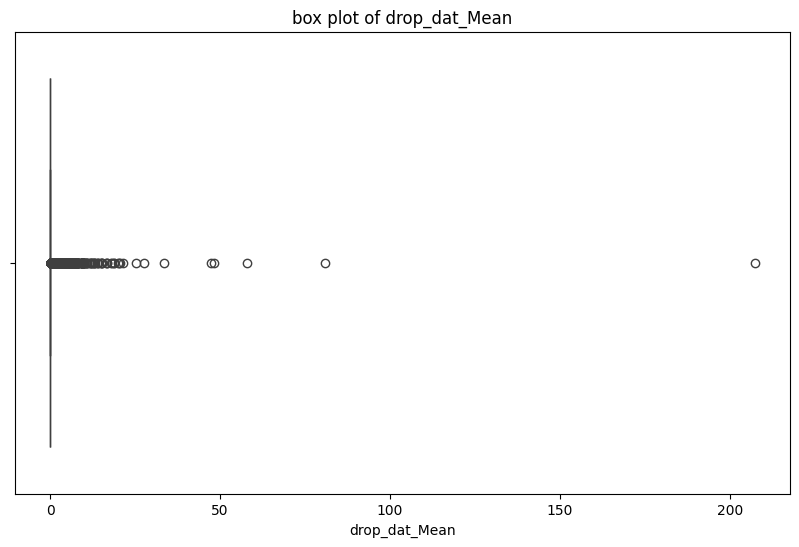

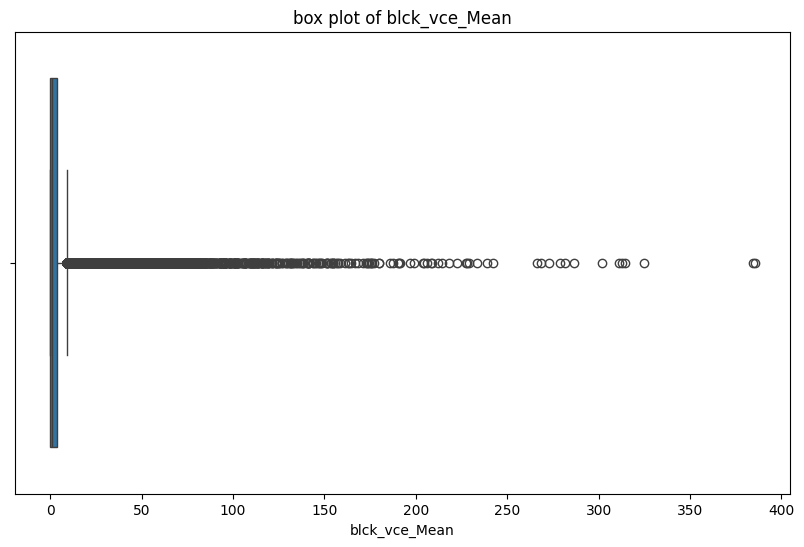

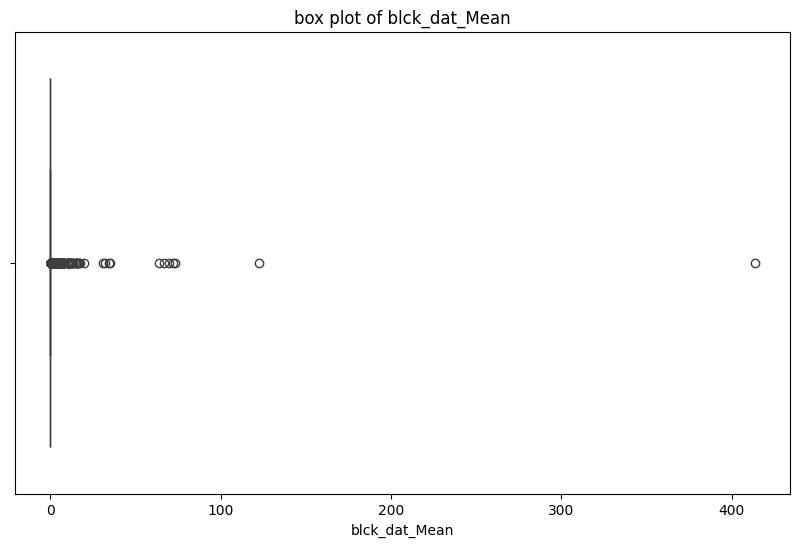

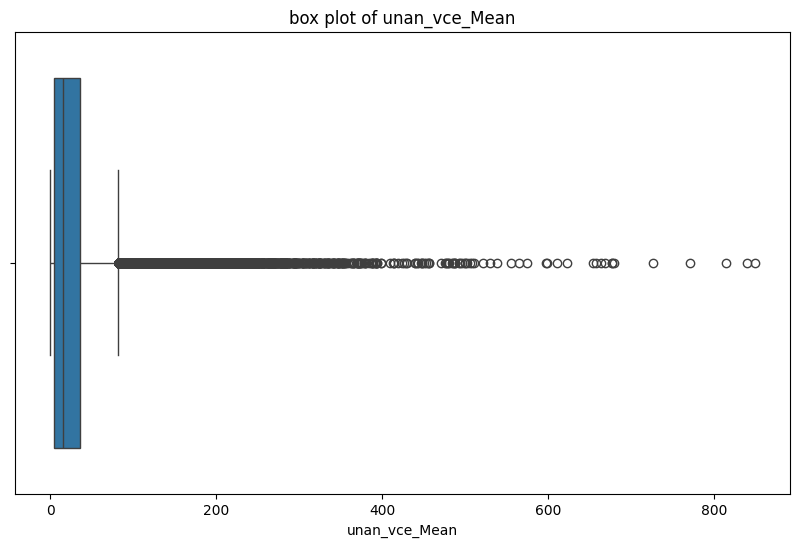

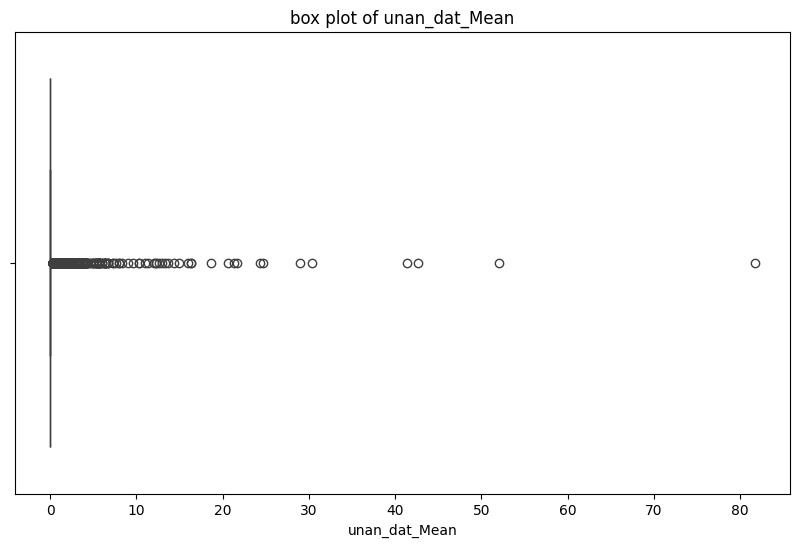

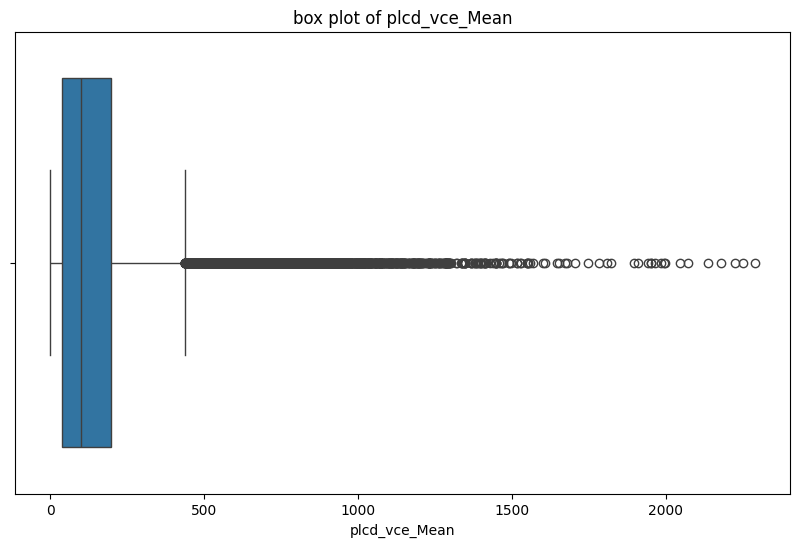

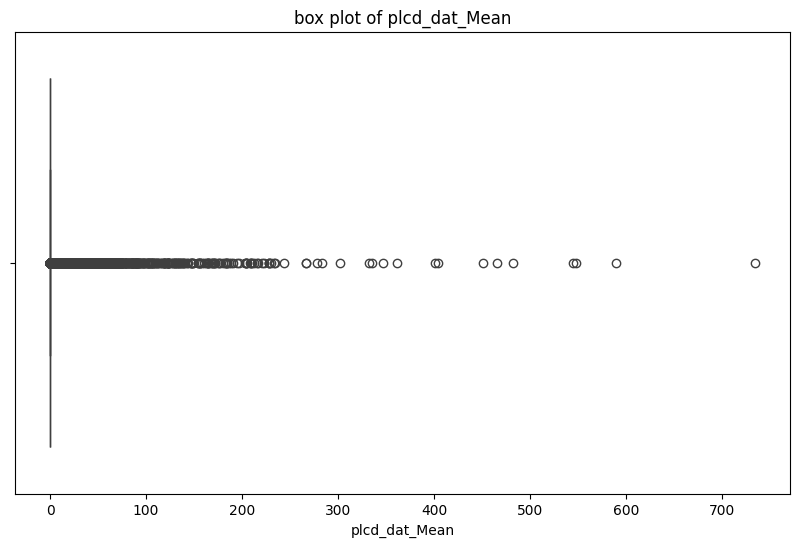

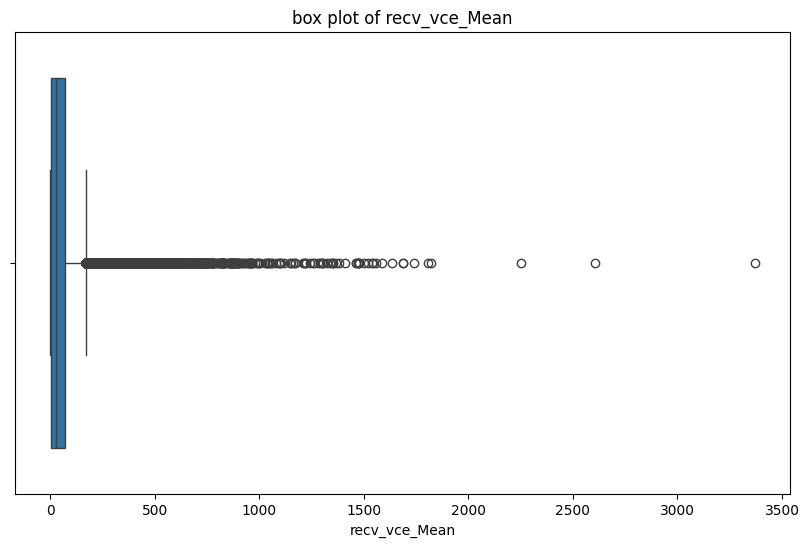

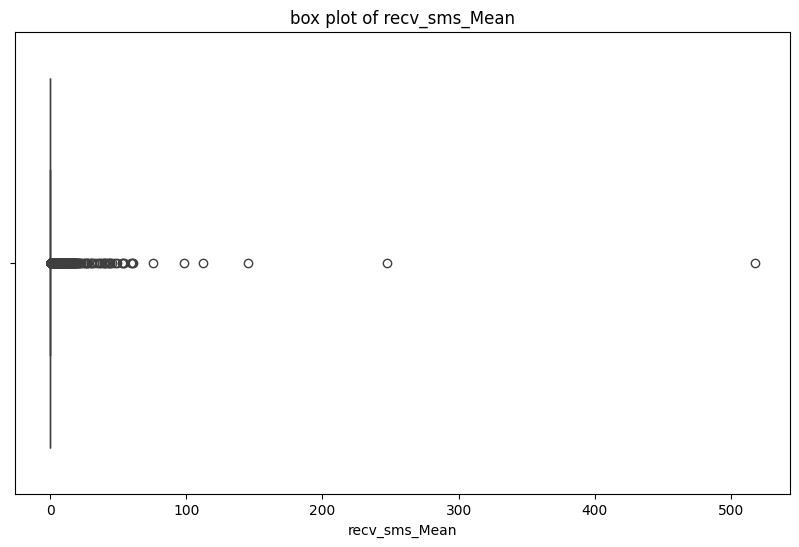

KeyboardInterrupt: 

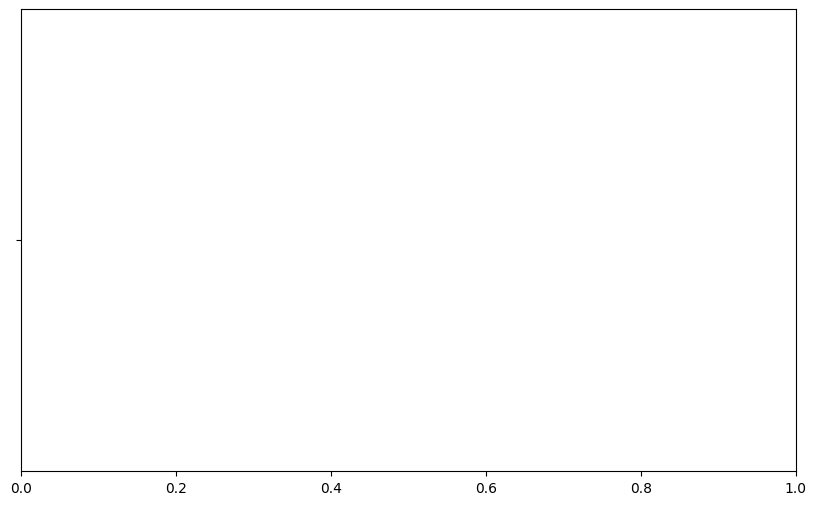

In [ ]:
numeric_features = df.select_dtypes(include=np.number).columns

for feature in numeric_features:
  plt.figure(figsize=(10, 6))
  sns.boxplot(x=df[feature])
  plt.title(f'box plot of {feature}')
  plt.show()

In [ ]:
# ── Outlier Capping (IQR Winsorizing) ─────────────────────────────────────
# Hanya diterapkan pada kolom numerik kontinyu
# Kolom biner (churn, creditcd), ID (Customer_ID), kategorik → DILEWATI

# Kolom yang DIKECUALIKAN dari capping
#exclude_cols = [
#    "churn",           # target variable — jangan diubah
#    "Customer_ID",     # ID pelanggan
#    "creditcd",        # biner (0/1)
#    "asl_flag",        # biner
#    "new_cell",        # biner
#    "months",          # jumlah bulan — distribusinya wajar lebar
#    "uniqsubs",        # jumlah subscriber — diskrit
#    "actvsubs",        # jumlah subscriber aktif — diskrit
#    "phones",          # jumlah handset — diskrit
#    "models",          # jumlah model — diskrit
#    "totcalls",        # total calls lifetime — biarkan apa adanya
#]

# Ambil semua kolom numerik, kecuali yang di-exclude
#numeric_cols = df.select_dtypes(include=["float64", "int64"]).columns.tolist()
#cols_to_cap  = [c for c in numeric_cols if c not in exclude_cols]

# Terapkan IQR capping
#capped_count = {}
#for col in cols_to_cap:
#    Q1  = df[col].quantile(0.25)
#    Q3  = df[col].quantile(0.75)
#    IQR = Q3 - Q1
#    lower = Q1 - 1.5 * IQR
#    upper = Q3 + 1.5 * IQR

#    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
#    if n_outliers > 0:
#        df[col] = df[col].clip(lower=lower, upper=upper)
#        capped_count[col] = n_outliers

# Ringkasan hasil
#print(f"Total kolom yang di-cap : {len(capped_count)}")
#print(f"Total kolom yang dilewati: {len(cols_to_cap) - len(capped_count)} (tidak ada outlier)\n")

#if capped_count:
#    print("Kolom yang memiliki outlier dan sudah di-cap:")
#    for col, count in capped_count.items():
#        print(f"  {col:<30} \u2192 {count:>5} nilai di-cap")
#else:
#    print("Tidak ada kolom yang memerlukan capping.")

#print("\nJumlah baris (non-null) pada masing-masing kolom setelah penanganan outlier:")
#print(df.info())

In [ ]:
#for feature in cols_to_cap:
#  plt.figure(figsize=(10, 6))
#  sns.boxplot(x=df[feature])
#  plt.title(f'Box plot of {feature} after Outlier Capping')
#  plt.show()

In [ ]:
# Kolom yang DIKECUALIKAN dari capping (sesuai diskusi sebelumnya)
exclude_cols = [
    "churn", "Customer_ID", "creditcd", "asl_flag", "new_cell",
    "months", "uniqsubs", "actvsubs", "phones", "models", "totcalls",
    # Tambahkan fitur revenue/usage — biarkan XGBoost/LGBM handle
    "totrev", "totmou", "adjrev", "adjmou", "avgrev", "avgmou",
]

numeric_cols = df.select_dtypes(include=["float64", "int64"]).columns.tolist()
cols_to_cap = [c for c in numeric_cols if c not in exclude_cols]

for col in cols_to_cap:
    lower_limit = df[col].quantile(0.005)  # P0.5
    upper_limit = df[col].quantile(0.995)  # P99.5
    df[col] = df[col].clip(lower=lower_limit, upper=upper_limit)

In [ ]:
skewed_cols = ['rev_Mean', 'mou_Mean', 'totrev', 'totmou', 'adjrev',
               'adjmou', 'avgrev', 'avgmou', 'avg3rev', 'avg6rev']

for col in skewed_cols:
    if (df[col] >= 0).all():  # pastikan tidak ada nilai negatif
        df[col + '_log'] = np.log1p(df[col])  # log(1+x) aman untuk nilai 0

In [ ]:
OVERAGE_COLS = [
    "ovrmou_Mean", "vceovr_Mean", "ovrrev_Mean", "datovr_Mean",
]

# Binary flag + log untuk kolom overage (zero-inflated)
overage_exist = [c for c in OVERAGE_COLS if c in df.columns]
for col in overage_exist:
    df[col + "_flag"] = (df[col] > 0).astype(int)
    df[col + "_log"] = np.log1p(df[col])

In [ ]:
# Visualisasi kolom yang di-cap
#for feature in cols_to_cap:
#    fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True,
#                             gridspec_kw={"height_ratios": (.8, .2)})
#
#    sns.histplot(df[feature], kde=True, ax=axes[0])
#    axes[0].set_title(f'Distribusi {feature} Setelah Percentile Capping (P0.5-P99.5)')

#    sns.boxplot(x=df[feature], ax=axes[1])
#    axes[1].set_title(f'Boxplot {feature}')

#    plt.tight_layout()
#    plt.show()

# ── Tambahkan ini: Visualisasi kolom log transform ──
#log_cols = [col + '_log' for col in skewed_cols if col + '_log' in df.columns]

#for feature in log_cols:
#    fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True,
#                             gridspec_kw={"height_ratios": (.8, .2)})

#    sns.histplot(df[feature], kde=True, ax=axes[0])
#    axes[0].set_title(f'Distribusi {feature} (Log Transform)')

#    sns.boxplot(x=df[feature], ax=axes[1])
#    axes[1].set_title(f'Boxplot {feature}')

#    plt.tight_layout()
#    plt.show()

In [ ]:
print("Informasi DataFrame setelah pre-processing:")
df.info()

Informasi DataFrame setelah pre-processing:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Columns: 111 entries, rev_Mean to datovr_Mean_log
dtypes: float64(83), int64(11), object(17)
memory usage: 84.7+ MB


In [ ]:
print("Jumlah missing values per kolom setelah pre-processing:")
df.isnull().sum().to_frame().style.set_properties(**{'border':'solid 1.5px #1c1c1c','background':'rgba(150,214,214,0.4)'})

Jumlah missing values per kolom setelah pre-processing:


,0
rev_Mean,0
mou_Mean,0
totmrc_Mean,0
da_Mean,0
ovrmou_Mean,0
ovrrev_Mean,0
vceovr_Mean,0
datovr_Mean,0
roam_Mean,0
change_mou,0


In [ ]:
df.loc[:100, ['rev_Mean', 'mou_Mean', 'totmrc_Mean', 'da_Mean', 'ovrmou_Mean', 'ovrrev_Mean', 'vceovr_Mean', 'datovr_Mean', 'roam_Mean', 'change_mou', 'change_rev', 'drop_vce_Mean', 'drop_dat_Mean', 'blck_vce_Mean', 'blck_dat_Mean', 'unan_vce_Mean', 'unan_dat_Mean', 'plcd_vce_Mean', 'plcd_dat_Mean', 'recv_vce_Mean', 'recv_sms_Mean', 'comp_vce_Mean', 'comp_dat_Mean', 'custcare_Mean', 'ccrndmou_Mean', 'cc_mou_Mean', 'inonemin_Mean', 'threeway_Mean', 'mou_cvce_Mean', 'mou_cdat_Mean', 'mou_rvce_Mean', 'owylis_vce_Mean', 'mouowylisv_Mean', 'iwylis_vce_Mean', 'mouiwylisv_Mean', 'peak_vce_Mean', 'peak_dat_Mean', 'mou_peav_Mean', 'mou_pead_Mean', 'opk_vce_Mean', 'opk_dat_Mean', 'mou_opkv_Mean', 'mou_opkd_Mean', 'drop_blk_Mean', 'attempt_Mean', 'complete_Mean', 'callfwdv_Mean', 'callwait_Mean', 'churn', 'months','uniqsubs', 'actvsubs', 'new_cell', 'crclscod', 'asl_flag', 'totcalls', 'totmou', 'totrev', 'adjrev', 'adjmou', 'adjqty', 'avgrev', 'avgmou', 'avgqty', 'avg3mou', 'avg3qty', 'avg3rev', 'avg6mou', 'avg6qty', 'avg6rev', 'area', 'dualband', 'refurb_new', 'hnd_price', 'phones', 'models', 'truck', 'rv', 'marital', 'forgntvl', 'ethnic', 'kid0_2', 'kid3_5', 'kid6_10', 'kid11_15', 'kid16_17', 'creditcd', 'eqpdays']].style.set_properties(**{'border':'solid 1.5px #1c1c1c','background':'rgba(150,214,214,0.4)'})

,rev_Mean,mou_Mean,totmrc_Mean,da_Mean,ovrmou_Mean,ovrrev_Mean,vceovr_Mean,datovr_Mean,roam_Mean,change_mou,change_rev,drop_vce_Mean,drop_dat_Mean,blck_vce_Mean,blck_dat_Mean,unan_vce_Mean,unan_dat_Mean,plcd_vce_Mean,plcd_dat_Mean,recv_vce_Mean,recv_sms_Mean,comp_vce_Mean,comp_dat_Mean,custcare_Mean,ccrndmou_Mean,cc_mou_Mean,inonemin_Mean,threeway_Mean,mou_cvce_Mean,mou_cdat_Mean,mou_rvce_Mean,owylis_vce_Mean,mouowylisv_Mean,iwylis_vce_Mean,mouiwylisv_Mean,peak_vce_Mean,peak_dat_Mean,mou_peav_Mean,mou_pead_Mean,opk_vce_Mean,opk_dat_Mean,mou_opkv_Mean,mou_opkd_Mean,drop_blk_Mean,attempt_Mean,complete_Mean,callfwdv_Mean,callwait_Mean,churn,months,uniqsubs,actvsubs,new_cell,crclscod,asl_flag,totcalls,totmou,totrev,adjrev,adjmou,adjqty,avgrev,avgmou,avgqty,avg3mou,avg3qty,avg3rev,avg6mou,avg6qty,avg6rev


### Melihat data yg perlu dilakukan encoding

In [ ]:
category_features = df.select_dtypes(include=['object']).columns
df[category_features]

,new_cell,crclscod,asl_flag,area,dualband,refurb_new,truck,rv,marital,forgntvl,ethnic,kid0_2,kid3_5,kid6_10,kid11_15,kid16_17,creditcd
0,U,A,N,NORTHWEST/ROCKY MOUNTAIN AREA,Y,N,0.0,0.0,S,0.0,N,U,U,U,U,U,Y
1,N,EA,N,CHICAGO AREA,N,N,1.0,1.0,S,0.0,Z,U,U,U,U,U,Y
2,Y,C,N,GREAT LAKES AREA,N,N,0.0,0.0,M,0.0,N,U,Y,U,U,U,Y
3,Y,B,N,CHICAGO AREA,N,N,0.0,0.0,M,0.0,U,Y,U,U,U,U,Y
4,Y,A,N,NEW ENGLAND AREA,Y,N,0.0,0.0,S,0.0,I,U,U,U,U,U,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,U,B,N,LOS ANGELES AREA,N,N,0.0,0.0,M,0.0,S,U,U,U,Y,U,Y
99996,U,CY,Y,LOS ANGELES AREA,N,N,0.0,0.0,M,0.0,N,U,U,Y,Y,Y,Y
99997,U,DA,N,SOUTHWEST AREA,Y,N,0.0,0.0,B,0.0,U,Y,Y,U,U,U,N
99998,U,EA,N,SOUTHWEST AREA,Y,N,0.0,0.0,U,0.0,S,U,U,U,U,U,N


### Label encoding

In [ ]:
label_encoder = LabelEncoder()
df_lencoder = pd.DataFrame(df)

for col in category_features:
  # Convert all values in the column to string type before encoding
  df_lencoder[col] = df_lencoder[col].astype(str)
  df_lencoder[col] = label_encoder.fit_transform(df_lencoder[col])

df_lencoder

,rev_Mean,mou_Mean,totmrc_Mean,da_Mean,ovrmou_Mean,ovrrev_Mean,vceovr_Mean,datovr_Mean,roam_Mean,change_mou,...,avg3rev_log,avg6rev_log,ovrmou_Mean_flag,ovrmou_Mean_log,vceovr_Mean_flag,vceovr_Mean_log,ovrrev_Mean_flag,ovrrev_Mean_log,datovr_Mean_flag,datovr_Mean_log
0,23.9975,219.25,22.500,0.2475,0.00,0.0,0.0000,0.0,0.0,-157.25,...,3.433987,3.663562,0,0.000000,0,0.000000,0,0.000000,0,0.0
1,57.4925,482.75,37.425,0.2475,22.75,9.1,9.1000,0.0,0.0,532.25,...,3.713572,3.891820,1,3.167583,1,2.312535,1,2.312535,0,0.0
2,16.9900,10.25,16.990,0.0000,0.00,0.0,0.0000,0.0,0.0,-4.25,...,2.890372,2.890372,0,0.000000,0,0.000000,0,0.000000,0,0.0
3,38.0000,7.50,38.000,0.0000,0.00,0.0,0.0000,0.0,0.0,-1.50,...,3.663562,3.713572,0,0.000000,0,0.000000,0,0.000000,0,0.0
4,55.2300,570.50,71.980,0.0000,0.00,0.0,0.0000,0.0,0.0,38.50,...,4.025352,4.394449,0,0.000000,0,0.000000,0,0.000000,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,48.1950,355.50,44.990,0.2475,2.75,1.0,0.6825,0.0,0.0,-6.25,...,4.304065,4.615121,1,1.321756,1,0.520281,1,0.693147,0,0.0
99996,48.1950,355.50,44.990,0.2475,2.75,1.0,0.6825,0.0,0.0,-6.25,...,4.304065,4.248495,1,1.321756,1,0.520281,1,0.693147,0,0.0
99997,48.1950,355.50,44.990,0.2475,2.75,1.0,0.6825,0.0,0.0,-6.25,...,4.127134,4.290459,1,1.321756,1,0.520281,1,0.693147,0,0.0
99998,48.1950,355.50,44.990,0.2475,2.75,1.0,0.6825,0.0,0.0,-6.25,...,5.003946,5.111988,1,1.321756,1,0.520281,1,0.693147,0,0.0


In [ ]:
selected_columns = [
    'new_cell', 'crclscod', 'asl_flag', 'area', 'dualband', 'refurb_new',
    'truck', 'rv', 'marital', 'forgntvl', 'ethnic', 'kid0_2', 'kid3_5',
    'kid6_10', 'kid11_15', 'kid16_17', 'creditcd'
]

# Display the selected columns from the label encoded DataFrame
df_lencoder[selected_columns].head()

,new_cell,crclscod,asl_flag,area,dualband,refurb_new,truck,rv,marital,forgntvl,ethnic,kid0_2,kid3_5,kid6_10,kid11_15,kid16_17,creditcd
0,1,0,0,13,4,0,0,0,3,0,9,0,0,0,0,0,2
1,0,21,0,3,0,0,1,1,3,0,17,0,0,0,0,0,2
2,2,7,0,6,0,0,0,0,2,0,9,0,2,0,0,0,2
3,2,4,0,3,0,0,0,0,2,0,14,2,0,0,0,0,2
4,2,0,0,10,4,0,0,0,3,0,6,0,0,0,0,0,2


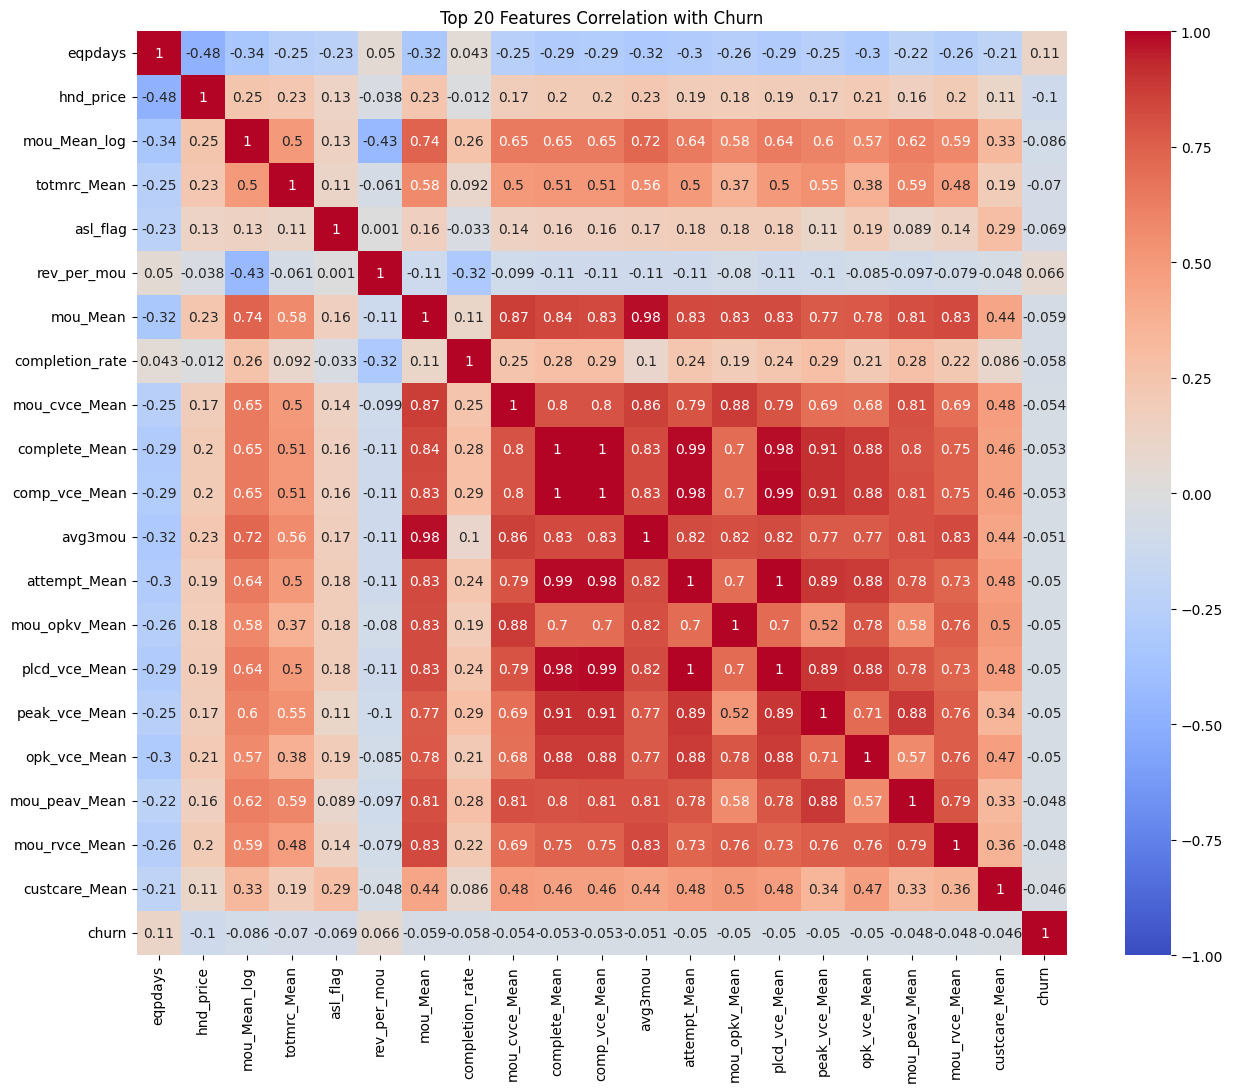

In [ ]:
correlation_matrix = df_lencoder.corr()

# Calculate correlations with 'churn' and sort them
churn_correlations = correlation_matrix['churn'].abs().sort_values(ascending=False)

# Select top N features (e.g., 20, excluding 'churn' itself)
top_features = churn_correlations.index[1:21].tolist() # Exclude 'churn' itself, take next 20

# Create a smaller correlation matrix for these top features
smaller_correlation_matrix = df_lencoder[top_features + ['churn']].corr()

# Plot the heatmap for the smaller matrix
plt.figure(figsize=(15, 12)) # Adjust figure size for the smaller matrix
sns.heatmap(smaller_correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Top 20 Features Correlation with Churn')
plt.show()

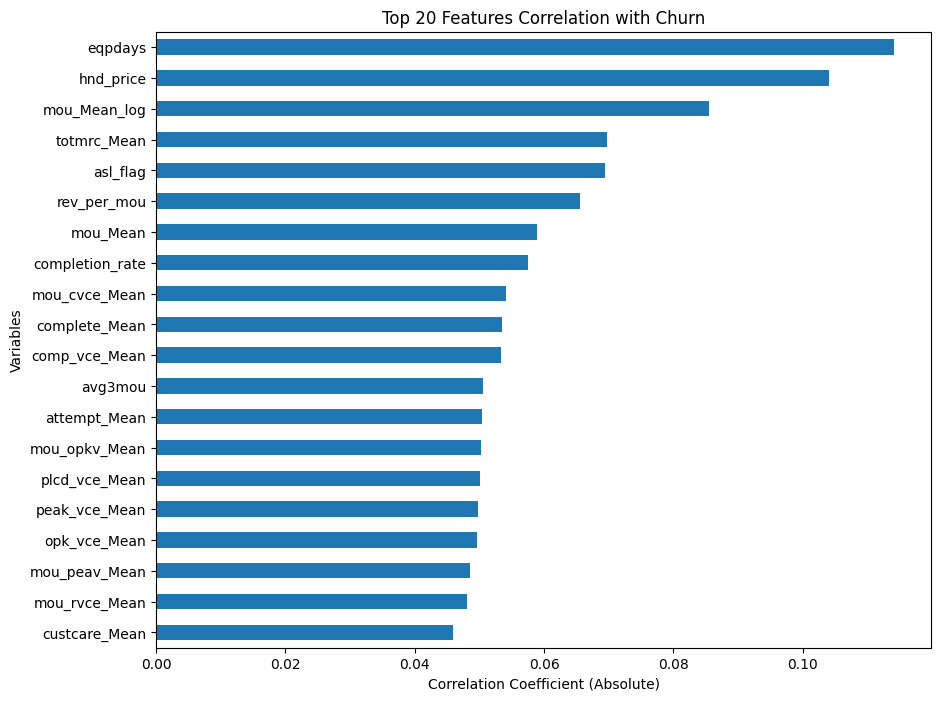

In [ ]:
# Menghitung korelasi antara variable target dan semua variable lainnya
target_corr = df_lencoder.corr()['churn']

# Mengurutkan hasil korelasi berdasarkan nilai absolut secara menurun
target_corr_sorted = target_corr.abs().sort_values(ascending=False)

# Mengambil 20 fitur teratas (termasuk 'churn' itu sendiri, jadi kita ambil 21 lalu buang 'churn')
top_20_features = target_corr_sorted[1:21] # Mengambil top 20 selain 'churn' itu sendiri

plt.figure(figsize=(10, 8)) # Memperbesar ukuran plot untuk bar chart horizontal
top_20_features.plot(kind='barh') # Menggunakan barh (horizontal bar chart)
plt.title(f'Top 20 Features Correlation with Churn')
plt.xlabel('Correlation Coefficient (Absolute)')
plt.ylabel('Variables')
plt.gca().invert_yaxis() # Membalik urutan agar korelasi tertinggi di atas
plt.show()

### Feautre selection

In [ ]:
df.loc[:100, ['rev_Mean', 'mou_Mean', 'totmrc_Mean', 'da_Mean', 'ovrmou_Mean', 'ovrrev_Mean', 'vceovr_Mean', 'datovr_Mean', 'roam_Mean', 'change_mou', 'change_rev', 'drop_vce_Mean', 'drop_dat_Mean', 'blck_vce_Mean', 'blck_dat_Mean', 'unan_vce_Mean', 'unan_dat_Mean', 'plcd_vce_Mean', 'plcd_dat_Mean', 'recv_vce_Mean', 'recv_sms_Mean', 'comp_vce_Mean', 'comp_dat_Mean', 'custcare_Mean', 'ccrndmou_Mean', 'cc_mou_Mean', 'inonemin_Mean', 'threeway_Mean', 'mou_cvce_Mean', 'mou_cdat_Mean', 'mou_rvce_Mean', 'owylis_vce_Mean', 'mouowylisv_Mean', 'iwylis_vce_Mean', 'mouiwylisv_Mean', 'peak_vce_Mean', 'peak_dat_Mean', 'mou_peav_Mean', 'mou_pead_Mean', 'opk_vce_Mean', 'opk_dat_Mean', 'mou_opkv_Mean', 'mou_opkd_Mean', 'drop_blk_Mean', 'attempt_Mean', 'complete_Mean', 'callfwdv_Mean', 'callwait_Mean', 'churn', 'months','uniqsubs', 'actvsubs', 'new_cell', 'crclscod', 'asl_flag', 'totcalls', 'totmou', 'totrev', 'adjrev', 'adjmou', 'adjqty', 'avgrev', 'avgmou', 'avgqty', 'avg3mou', 'avg3qty', 'avg3rev', 'avg6mou', 'avg6qty', 'avg6rev', 'area', 'dualband', 'refurb_new', 'hnd_price', 'phones', 'models', 'truck', 'rv', 'marital', 'forgntvl', 'ethnic', 'kid0_2', 'kid3_5', 'kid6_10', 'kid11_15', 'kid16_17', 'creditcd', 'eqpdays', 'Customer_ID']].style.set_properties(**{'border':'solid 1.5px #1c1c1c','background':'rgba(150,214,214,0.4)'})

KeyError: "['Customer_ID'] not in index"

### data splitting

In [ ]:
# Memisahkan fitur (X) dan target (Y)
X = df_lencoder.drop(columns=['churn'])
y = df_lencoder['churn']

In [ ]:
# Membagi dataset menjadi training dan testing

# train size = 80% test_size = 20%
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1, stratify=y)

print("Jumlah data untuk target: ", len(X))
print("Jumlah data train untuk target: ", len(X_train))
print("Jumlah data test untuk target: ", len(X_test))

Jumlah data untuk target:  100000
Jumlah data train untuk target:  80000
Jumlah data test untuk target:  20000


### Memeriksa skala persebaran data

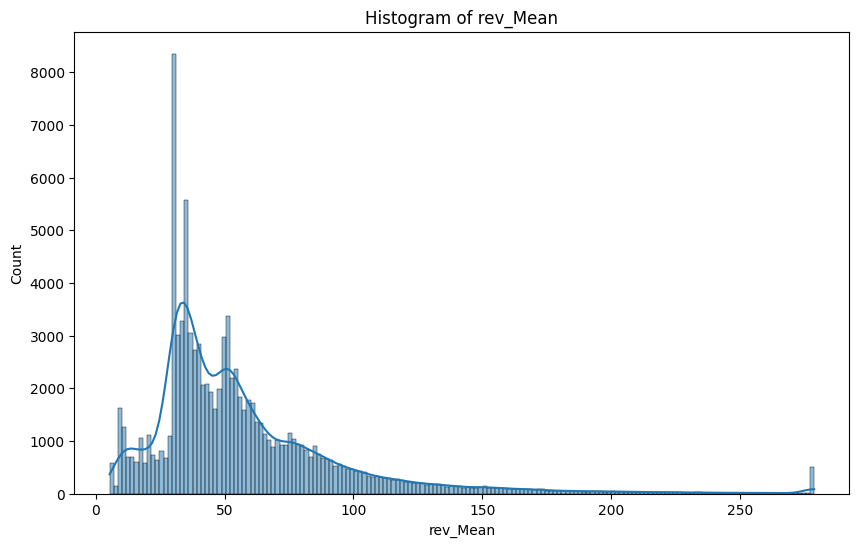

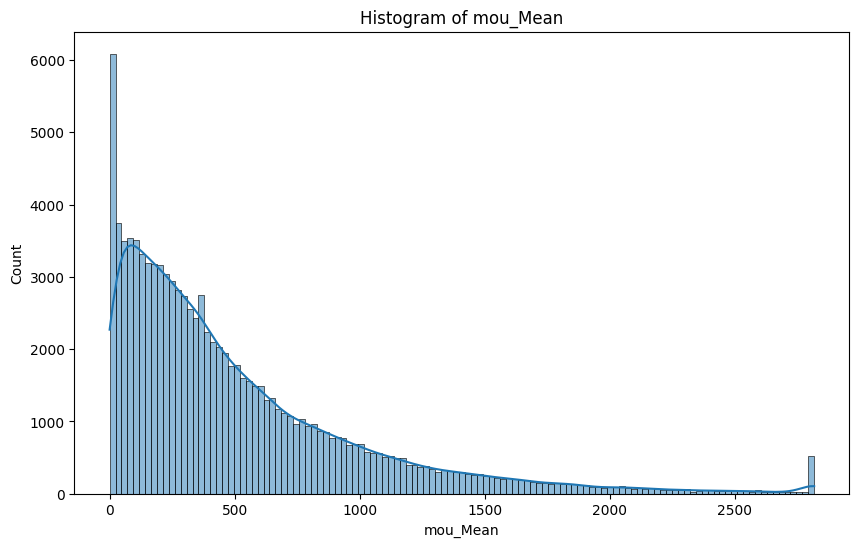

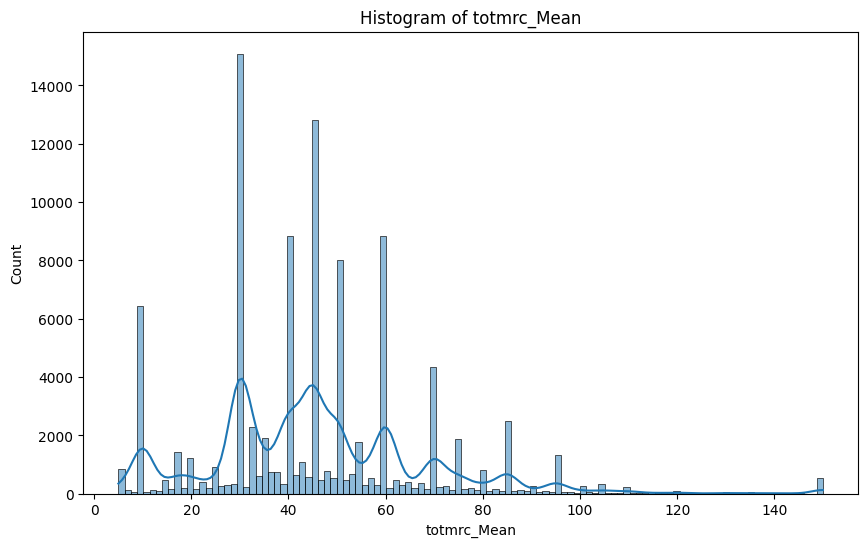

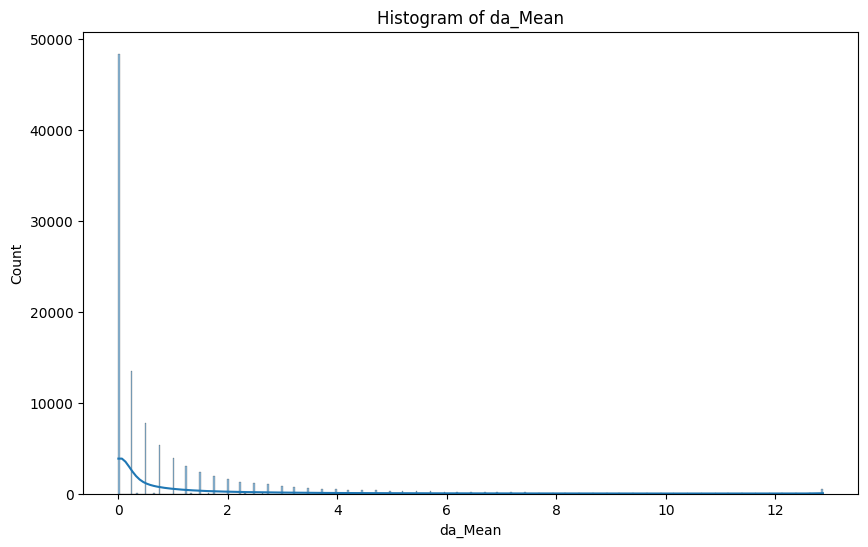

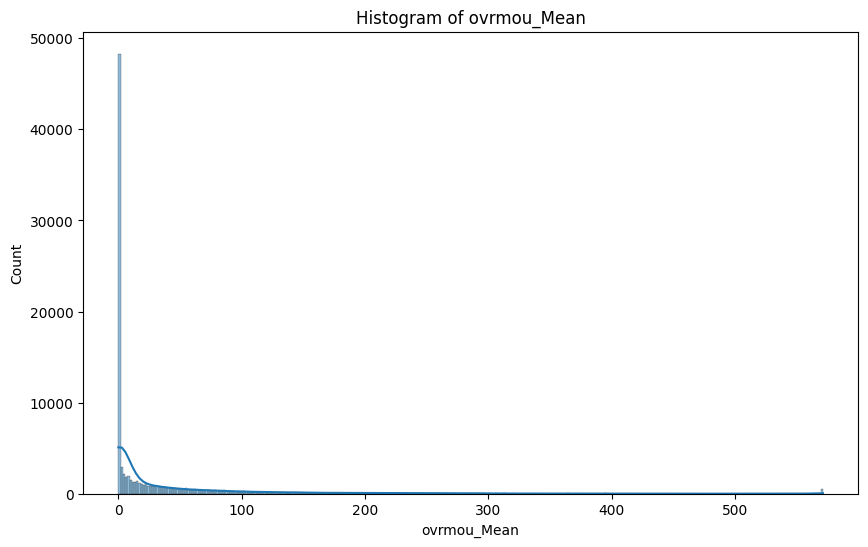

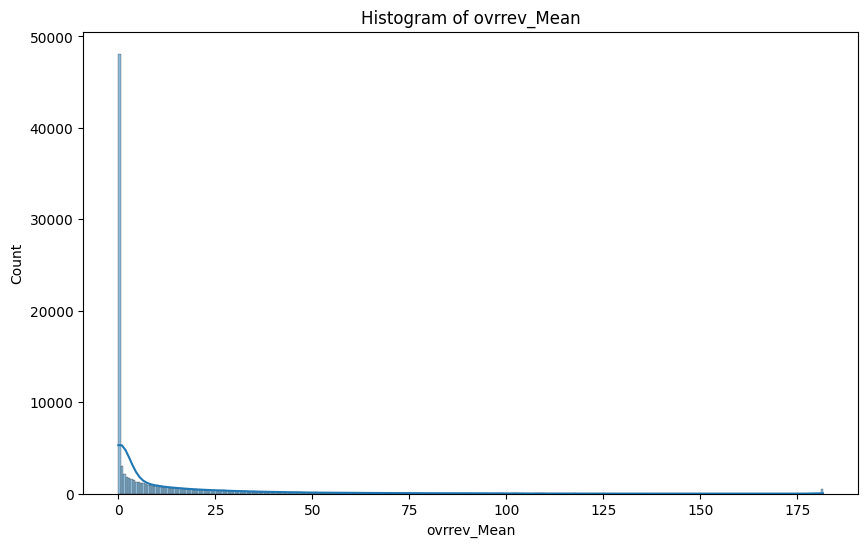

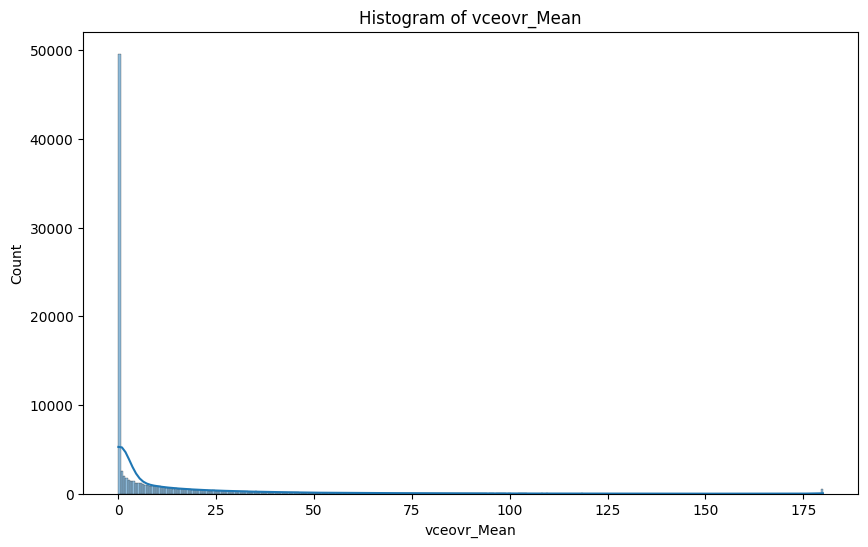

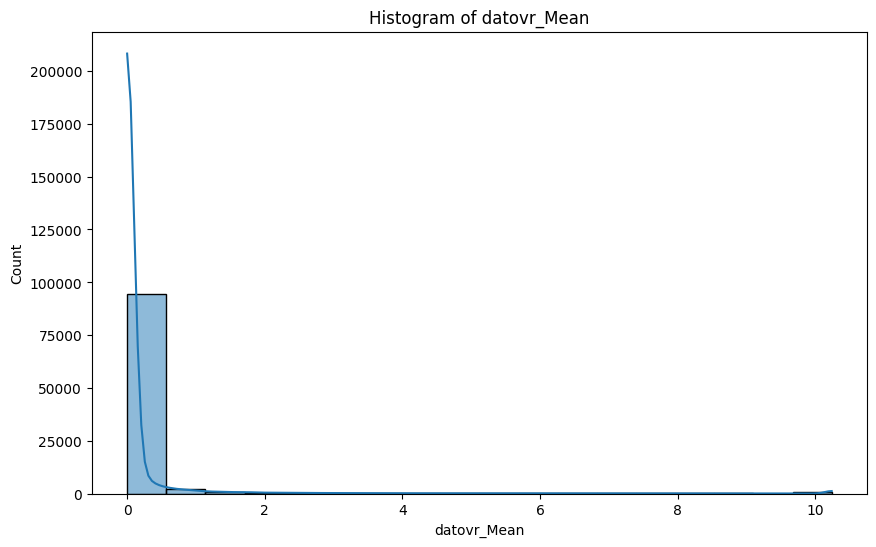

KeyboardInterrupt: 

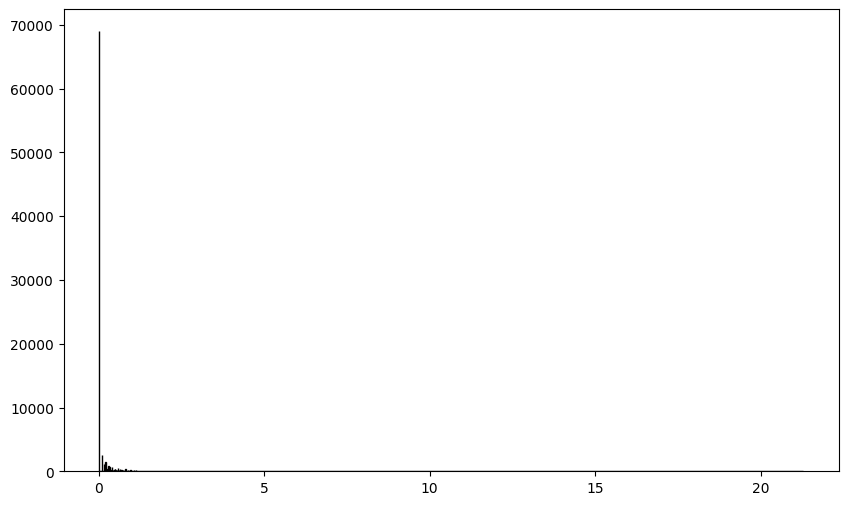

In [ ]:
for feature in df.select_dtypes(include=['number']).columns:
    plt.figure(figsize=(10, 6))
    sns.histplot(df[feature], kde=True)
    plt.title(f'Histogram of {feature}')
    plt.show()

### Melakukan Standarisasi

In [ ]:
# All columns in X_train are now numerical due to previous preprocessing steps (including label encoding).
# Therefore, we will scale all columns in X_train and X_test.
features_to_scale = X_train.columns

scaler = StandardScaler()

# Fit the scaler only on X_train and transform both X_train and X_test
X_train[features_to_scale] = scaler.fit_transform(X_train[features_to_scale])
X_test[features_to_scale] = scaler.transform(X_test[features_to_scale])

print("X_train after scaling (first 5 rows):")
print(X_train.head())
print("\nX_test after scaling (first 5 rows):")
print(X_test.head())

# The previous plotting of all histograms was removed for brevity and to focus on the scaling fix.
# If you wish to visualize the distribution of scaled features, you can add specific plotting code here.

X_train after scaling (first 5 rows):
       rev_Mean  mou_Mean  totmrc_Mean   da_Mean  ovrmou_Mean  ovrrev_Mean  \
73854 -0.153922 -0.508880     0.615632  0.352855    -0.484010    -0.495818   
63526 -0.132126 -0.477146    -0.597110 -0.341043    -0.265369    -0.260028   
51956 -0.690519 -0.582267    -0.268694 -0.479823    -0.484010    -0.495818   
27077 -0.344201 -0.402272    -0.163570 -0.479823    -0.299243    -0.268093   
54361 -0.776154 -0.965066    -0.887611 -0.479823    -0.484010    -0.495818   

       vceovr_Mean  datovr_Mean  roam_Mean  change_mou  ...  avg3rev_log  \
73854    -0.491285    -0.180767  -0.263999    0.522135  ...     0.117771   
63526    -0.253032    -0.180767   4.283659    0.304263  ...    -0.300506   
51956    -0.491285    -0.180767  -0.263999    0.218823  ...    -0.704308   
27077    -0.261182    -0.180767  -0.263999   -0.643055  ...    -0.113022   
54361    -0.491285    -0.180767  -0.239050   -0.037498  ...    -0.981127   

       avg6rev_log  ovrmou_Mean_flag

### (smote) Imbalance class handling

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

In [ ]:
import os

# Combine X_train_sm and y_train_sm into a single DataFrame
smote_data_df = X_train_sm.copy()
smote_data_df['churn'] = y_train_sm

# Define the directory and filename for the SMOTE data
output_dir = 'ml/data'
output_filename = 'smote_train_data.csv'
output_path = os.path.join(output_dir, output_filename)

# Create the directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

# Save the DataFrame to a CSV file
smote_data_df.to_csv(output_path, index=False)

print(f"Data hasil SMOTE berhasil disimpan ke: {output_path}")
print(f"Jumlah baris data hasil SMOTE: {len(smote_data_df)}")
print("Berikut adalah 5 baris pertama dari data hasil SMOTE:")
print(smote_data_df.head())

Data hasil SMOTE berhasil disimpan ke: ml/data/smote_train_data.csv
Jumlah baris data hasil SMOTE: 80700
Berikut adalah 5 baris pertama dari data hasil SMOTE:
   rev_Mean  mou_Mean  totmrc_Mean   da_Mean  ovrmou_Mean  ovrrev_Mean  \
0 -0.153922 -0.508880     0.615632  0.352855    -0.484010    -0.495818   
1 -0.132126 -0.477146    -0.597110 -0.341043    -0.265369    -0.260028   
2 -0.690519 -0.582267    -0.268694 -0.479823    -0.484010    -0.495818   
3 -0.344201 -0.402272    -0.163570 -0.479823    -0.299243    -0.268093   
4 -0.776154 -0.965066    -0.887611 -0.479823    -0.484010    -0.495818   

   vceovr_Mean  datovr_Mean  roam_Mean  change_mou  ...  avg6rev_log  \
0    -0.491285    -0.180767  -0.263999    0.522135  ...     0.090327   
1    -0.253032    -0.180767   4.283659    0.304263  ...    -0.200714   
2    -0.491285    -0.180767  -0.263999    0.218823  ...    -0.807104   
3    -0.261182    -0.180767  -0.263999   -0.643055  ...    -0.049247   
4    -0.491285    -0.180767  -0.2390

### Visualisasi Data setelah Standarisasi

Kita akan melihat distribusi beberapa fitur setelah standarisasi. Idealnya, distribusi harus terpusat di sekitar 0 dengan standar deviasi 1.

Visualizing scaled X_train features:


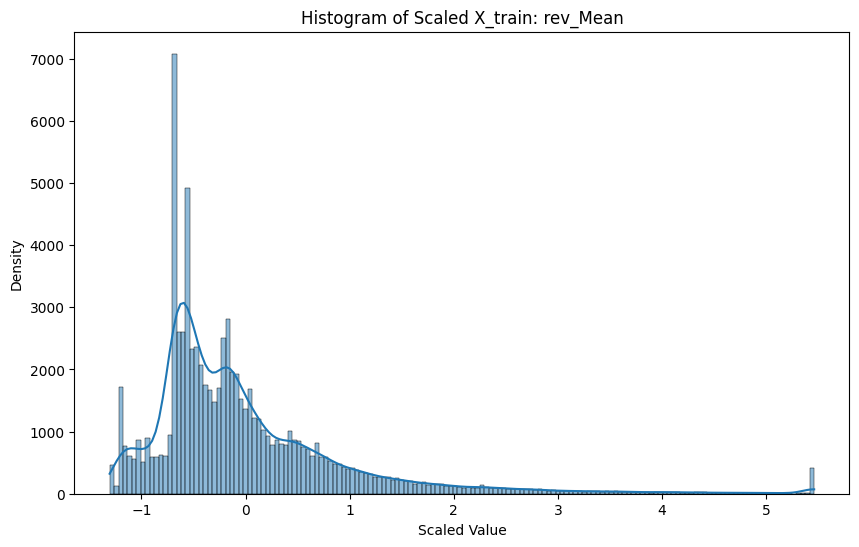

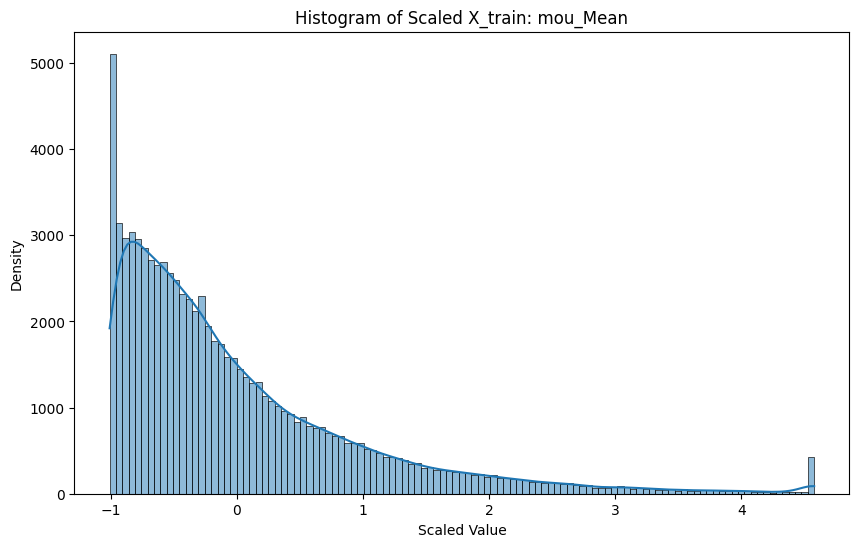

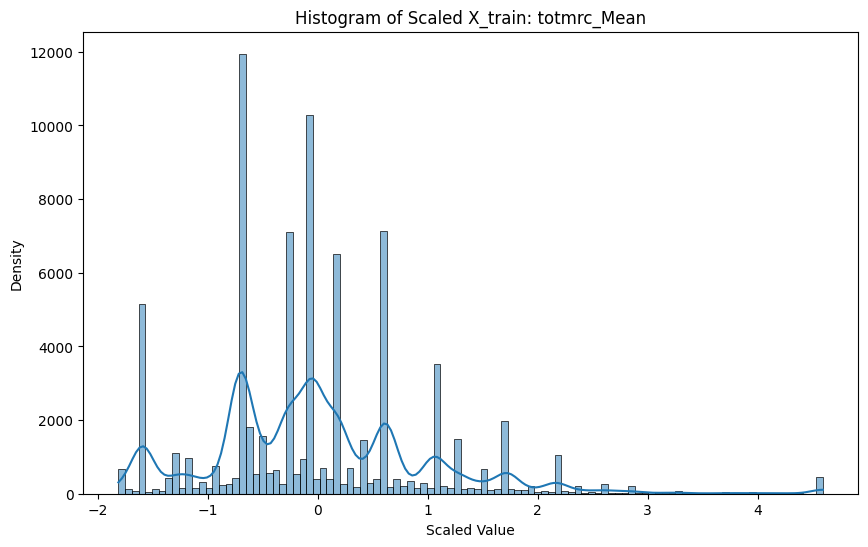

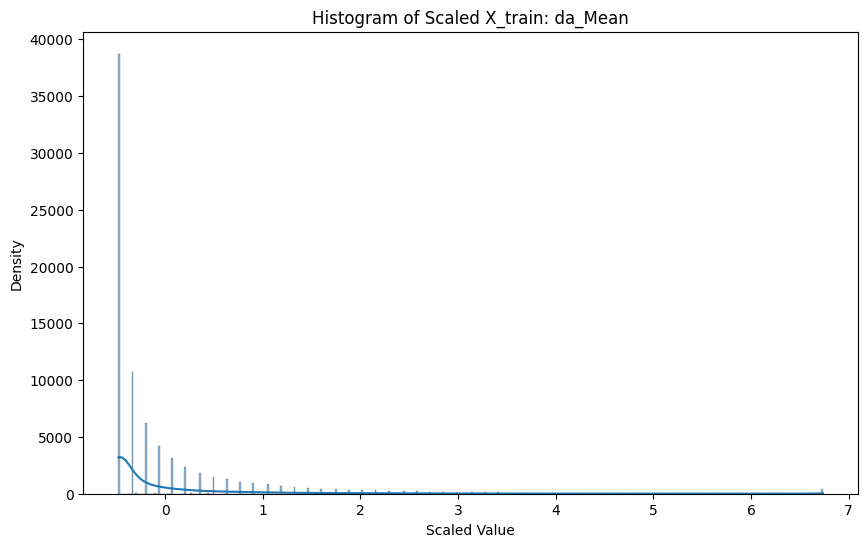

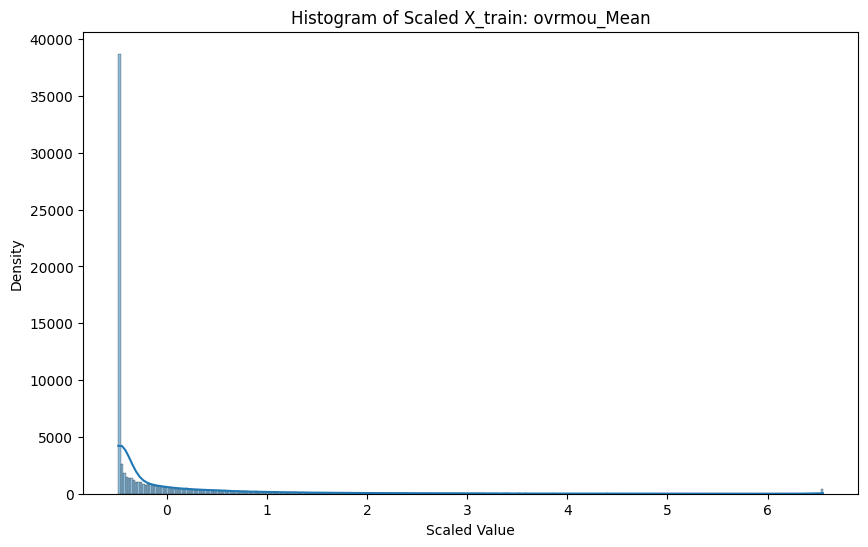

Visualizing scaled X_test features:


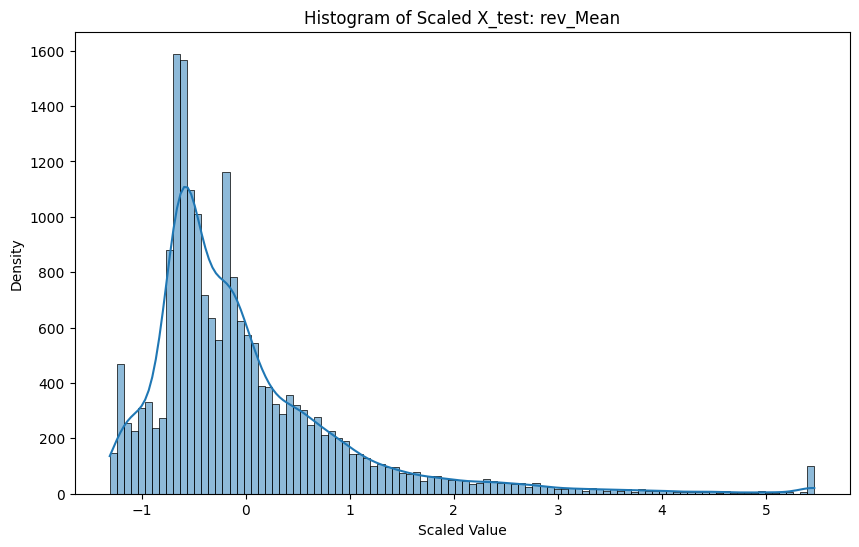

KeyboardInterrupt: 

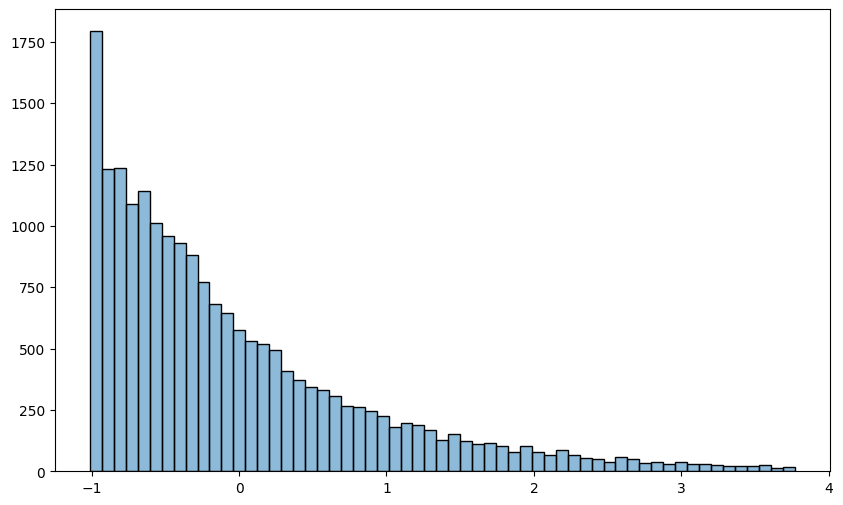

In [ ]:
# Visualize distributions of a few scaled features from X_train
print("Visualizing scaled X_train features:")
for feature in features_to_scale[:5]: # Plotting first 5 features for brevity
    plt.figure(figsize=(10, 6))
    sns.histplot(X_train[feature], kde=True)
    plt.title(f'Histogram of Scaled X_train: {feature}')
    plt.xlabel('Scaled Value')
    plt.ylabel('Density')
    plt.show()

# Visualize distributions of a few scaled features from X_test
print("Visualizing scaled X_test features:")
for feature in features_to_scale[:5]: # Plotting first 5 features for brevity
    plt.figure(figsize=(10, 6))
    sns.histplot(X_test[feature], kde=True)
    plt.title(f'Histogram of Scaled X_test: {feature}')
    plt.xlabel('Scaled Value')
    plt.ylabel('Density')
    plt.show()

# **5. Data modeling**

### LightGBM

In [ ]:
from lightgbm import LGBMClassifier

# Note: class_weight calculation for lgb.Dataset is not directly needed for LGBMClassifier
# when using is_unbalance=True, as LGBMClassifier handles it internally.
# If explicit scale_pos_weight is desired, calculate it like this:
# scale_pos_weight = len(y_train_sm[y_train_sm==0]) / len(y_train_sm[y_train_sm==1])

# Define model with parameters
lgb_model = LGBMClassifier(
    objective='binary',
    metric='auc',
    boosting_type='gbdt',
    num_leaves=31,
    learning_rate=0.05,
    colsample_bytree=0.9,
    subsample=0.8,
    subsample_freq=5,
    n_estimators=1000,
    is_unbalance=True,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

lgb_model.fit(
    X_train_sm, y_train_sm,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
)
# Make predictions
y_pred_proba_lgb = lgb_model.predict_proba(X_test)[:, 1]
y_pred_lgb = (y_pred_proba_lgb >= 0.5).astype(int)

# Evaluate
print("LightGBM Classification Report:")
print(classification_report(y_test, y_pred_lgb))

# Plot feature importance
plt.figure(figsize=(10, 6))
feat_importances_lgb = pd.Series(lgb_model.feature_importances_, index=X_train_sm.columns)
feat_importances_lgb.nlargest(10).plot(kind='barh')
plt.title('LightGBM Feature Importance')
plt.show()

precision_lgb, recall_lgb, thresholds_lgb = precision_recall_curve(y_test, y_pred_proba_lgb)
f1_scores_lgb = 2 * (precision_lgb * recall_lgb) / (precision_lgb + recall_lgb + 1e-10)
optimal_idx = np.argmax(f1_scores_lgb)
optimal_threshold_lgb = thresholds_lgb[optimal_idx] if optimal_idx < len(thresholds_lgb) else 0.5

# Apply optimal threshold
y_pred_lgb_optimal = (y_pred_proba_lgb >= optimal_threshold_lgb).astype(int)
print(f"Optimal threshold: {optimal_threshold_lgb}")
print("LightGBM Classification Report with Optimal Threshold:")
print(classification_report(y_test, y_pred_lgb_optimal))

#### lightbm feature selection

In [ ]:
from sklearn.feature_selection import SelectFromModel

# Gunakan feature importance dari LightGBM/XGBoost
selector = SelectFromModel(lgb_model, threshold='median')
selector.fit(X_train_sm, y_train_sm) # Fit the selector on the training data
X_train_sel = selector.transform(X_train_sm)
X_test_sel = selector.transform(X_test)

selected_feature_names = X_train_sm.columns[selector.get_support()]

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


In [ ]:
from sklearn.feature_selection import SelectFromModel
import joblib

# Load the LGBM model from the saved file
lgb_model = joblib.load('lgb_model.pkl')

# Gunakan feature importance dari LightGBM/XGBoost
selector = SelectFromModel(lgb_model, threshold='median', prefit=True) # Set prefit=True since the model is already fitted
# The selector no longer needs to be fitted if the model is already fitted
# selector.fit(X_train_sm, y_train_sm)
X_train_sel = selector.transform(X_train_sm)
X_test_sel = selector.transform(X_test)

selected_feature_names = X_train_sm.columns[selector.get_support()]

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


menyimpan model lgbm

In [ ]:
from sklearn.feature_selection import SelectFromModel

# Gunakan feature importance dari LightGBM/XGBoost
selector = SelectFromModel(lgb_model, threshold='median')
selector.fit(X_train, y_train) # Fit the selector on the training data, using original X_train for feature names consistency
X_train_sel = selector.transform(X_train)
X_test_sel = selector.transform(X_test)

### XGBoost Model

In [ ]:
!pip install xgboost

In [ ]:
import xgboost as xgb

# Recalculate scale_pos_weight with correct unscaled y_train
scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])

xgb_model = xgb.XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    learning_rate=0.1,
    n_estimators=100,
    max_depth=5,
    random_state=42,
    eval_metric = 'auc'
)

# Train model
xgb_model.fit(X_train_sel, y_train)

# Buat prediksi
y_pred_proba = xgb_model.predict_proba(X_test_sel)[:, 1]
y_pred = (y_pred_proba >= 0.5).astype(int)

# Evaluasi
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Visualisasikan Feature Importance
plt.figure(figsize=(10, 6))
xgb.plot_importance(xgb_model, max_num_features=10)
plt.title('XGBoost Feature Importance')
plt.show()

# Atur threshold
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
optimal_threshold = thresholds[np.argmax(f1_scores)]
print(f"Optimal threshold: {optimal_threshold}")

# Aplikasikan threshold
y_pred_optimal = (y_pred_proba >= optimal_threshold).astype(int)
print("Classification Report with Optimal Threshold:")
print(classification_report(y_test, y_pred_optimal))

In [ ]:
cm = confusion_matrix(y_test, y_pred_optimal)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

Menyimpan model XGBoost

In [ ]:
import pickle

In [ ]:
with open('xgb_model.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)
print("XGBoost model saved as xgb_model.pkl")

### Random forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Class weight dictionary or 'balanced' option
class_weights = {0: 1, 1: (len(y_train_sm[y_train_sm==0]) / len(y_train_sm[y_train_sm==1]))}
# Alternatively: class_weights = 'balanced'

# Define the model with class weights
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    bootstrap=True,
    class_weight=class_weights,
    random_state=42,
    n_jobs=-1
)

# Train the model
rf_model.fit(X_train_sel, y_train_sm)

# Make predictions
y_pred_proba_rf = rf_model.predict_proba(X_test_sel)[:, 1]
y_pred_rf = rf_model.predict(X_test_sel)

# Evaluate
print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

# Plot feature importance
plt.figure(figsize=(10, 6))
feat_importances = pd.Series(rf_model.feature_importances_, index=selector.get_feature_names_out())
feat_importances.nlargest(10).plot(kind='barh')
plt.title('Random Forest Feature Importance')
plt.show()

# Finding optimal threshold
precision_rf, recall_rf, thresholds_rf = precision_recall_curve(y_test, y_pred_proba_rf)
f1_scores_rf = 2 * (precision_rf * recall_rf) / (precision_rf + recall_rf + 1e-10)
optimal_threshold_rf = thresholds_rf[np.argmax(f1_scores_rf)]

# Apply optimal threshold
y_pred_rf_optimal = (y_pred_proba_rf >= optimal_threshold_rf).astype(int)
print(f"Optimal threshold: {optimal_threshold_rf}")
print("Random Forest Classification Report with Optimal Threshold:")
print(classification_report(y_test, y_pred_rf_optimal))

Menyimpan model Random Forest

In [ ]:
with open('rf_model.pkl', 'wb') as f:
    pickle.dump(rf_model, f)
print("Random Forest model saved as rf_model.pkl")

### Logistic regressor

In [ ]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    penalty='l2',
    C=1.0,
    solver='liblinear',
    class_weight='balanced',
    random_state=42,
    max_iter=1000
)

# Train the model
lr_model.fit(X_train_sel, y_train)

# Make predictions
y_pred_proba_lr = lr_model.predict_proba(X_test_sel)[:, 1]
y_pred_lr = lr_model.predict(X_test_sel)

# Evaluate
print("Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred_lr))

# Plot coefficient importance
plt.figure(figsize=(10, 6))
coefficients = pd.DataFrame({
    'Feature': selector.get_feature_names_out(),
    'Coefficient': lr_model.coef_[0]
})
coefficients = coefficients.reindex(coefficients['Coefficient'].abs().sort_values(ascending=False).index)
sns.barplot(x='Coefficient', y='Feature', data=coefficients.head(10))
plt.title('Logistic Regression Coefficients')
plt.show()

# Finding optimal threshold
precision_lr, recall_lr, thresholds_lr = precision_recall_curve(y_test, y_pred_proba_lr)
f1_scores_lr = 2 * (precision_lr * recall_lr) / (precision_lr + recall_lr + 1e-10)
optimal_threshold_lr = thresholds_lr[np.argmax(f1_scores_lr)]

# Apply optimal threshold
y_pred_lr_optimal = (y_pred_proba_lr >= optimal_threshold_lr).astype(int)
print(f"Optimal threshold: {optimal_threshold_lr}")
print("Logistic Regression Classification Report with Optimal Threshold:")
print(classification_report(y_test, y_pred_lr_optimal))

Menyimpan model Logistic Regression

In [ ]:
with open('lr_model.pkl', 'wb') as f:
    pickle.dump(lr_model, f)
print("Logistic Regression model saved as lr_model.pkl")

Menyimpan model LightGBM

In [ ]:
with open('lgb_model.pkl', 'wb') as f:
    pickle.dump(lgb_model, f)
print("LightGBM model saved as lgb_model.pkl")

### CatBoost

In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.5 MB/s eta 0:00:00


In [ ]:
from catboost import CatBoostClassifier, Pool

class_weights = {0: 1, 1: len(y_train_sm[y_train_sm==0]) / len(y_train_sm[y_train_sm==1])}

train_pool = Pool(X_train_sel, y_train_sm)
test_pool = Pool(X_test_sel, y_test)

catboost_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=42,
    verbose=100
)

# Train model
catboost_model.fit(
    train_pool,
    eval_set=test_pool,
    early_stopping_rounds=50,
)

# Make predictions
y_pred_proba_cat = catboost_model.predict_proba(X_test_sel)[:, 1]
y_pred_cat = catboost_model.predict(X_test_sel)

# Evaluate
print("CatBoost Classification Report:")
print(classification_report(y_test, y_pred_cat))

# Plot feature importance
plt.figure(figsize=(10, 6))
feature_importance = catboost_model.get_feature_importance()
sorted_idx = np.argsort(feature_importance)[-10:]
plt.barh(range(len(sorted_idx)), feature_importance[sorted_idx])
#plt.yticks(range(len(sorted_idx)), X_train_sel.columns[sorted_idx])
plt.yticks(range(len(sorted_idx)), selected_feature_names[sorted_idx])
plt.title('CatBoost Feature Importance')
plt.show()

# Optimal Threshold
precision_cat, recall_cat, thresholds_cat = precision_recall_curve(y_test, y_pred_proba_cat)
f1_scores_cat = 2 * (precision_cat * recall_cat) / (precision_cat + recall_cat + 1e-10)
optimal_idx = np.argmax(f1_scores_cat)
optimal_threshold_cat = thresholds_cat[optimal_idx] if optimal_idx < len(thresholds_cat) else 0.5

# Apply optimal threshold
y_pred_cat_optimal = (y_pred_proba_cat >= optimal_threshold_cat).astype(int)
print(f"Optimal threshold: {optimal_threshold_cat}")
print("CatBoost Classification Report with Optimal Threshold:")
print(classification_report(y_test, y_pred_cat_optimal))

Menyimpan model CatBoost

In [ ]:
with open('catboost_model.pkl', 'wb') as f:
    pickle.dump(catboost_model, f)
print("CatBoost model saved as catboost_model.pkl")

### Komparasi antar model

In [ ]:
def evaluate_model(y_true, y_pred, y_pred_proba, model_name):
    # Classification metrics
    print(f"\n{model_name} Evaluation:")
    print("Classification Report:")
    print(classification_report(y_true, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Not Churn', 'Churn'],
                yticklabels=['Not Churn', 'Churn'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'{model_name} Confusion Matrix')
    plt.show()

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_true, y_pred_proba)
    roc_auc = roc_auc_score(y_true, y_pred_proba)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'{model_name} ROC Curve')
    plt.legend(loc='lower right')
    plt.show()

    # Precision-Recall Curve
    precision, recall, _ = precision_recall_curve(y_true, y_pred_proba)
    pr_auc = auc(recall, precision)

    plt.figure(figsize=(8, 6))
    plt.plot(recall, precision, label=f'PR AUC = {pr_auc:.3f}')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'{model_name} Precision-Recall Curve')
    plt.legend(loc='upper right')
    plt.show()

    return {
        'model': model_name,
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred),
        'recall': recall_score(y_true, y_pred),
        'f1': f1_score(y_true, y_pred),
        'auc': roc_auc,
        'pr_auc': pr_auc
    }


In [ ]:
# Compare all models
from sklearn.metrics import roc_curve, auc, accuracy_score, precision_score, recall_score

# Evaluate each model
results = []
results.append(evaluate_model(y_test, y_pred_optimal, y_pred_proba, "XGBoost"))
results.append(evaluate_model(y_test, y_pred_rf_optimal, y_pred_proba_rf, "Random Forest"))
results.append(evaluate_model(y_test, y_pred_lr_optimal, y_pred_proba_lr, "Logistic Regression"))
results.append(evaluate_model(y_test, y_pred_lgb_optimal, y_pred_proba_lgb, "LightGBM"))
results.append(evaluate_model(y_test, y_pred_cat_optimal, y_pred_proba_cat, "CatBoost"))

# Create comparison table
results_df = pd.DataFrame(results)
print("\nModel Comparison:")
print(results_df)

# Plot comparison
plt.figure(figsize=(12, 6))
metrics = ['accuracy', 'precision', 'recall', 'f1', 'auc', 'pr_auc']
for metric in metrics:
    plt.figure(figsize=(10, 6))
    sns.barplot(x='model', y=metric, data=results_df)
    plt.title(f'Model Comparison - {metric.upper()}')
    plt.ylim(0, 1)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()# Create a function to evaluate and compare models
def evaluate_model(y_true, y_pred, y_pred_proba, model_name):
    # Classification metrics
    print(f"\n{model_name} Evaluation:")
    print("Classification Report:")
    print(classification_report(y_true, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Not Churn', 'Churn'],
                yticklabels=['Not Churn', 'Churn'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'{model_name} Confusion Matrix')
    plt.show()

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_true, y_pred_proba)
    roc_auc = roc_auc_score(y_true, y_pred_proba)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'{model_name} ROC Curve')
    plt.legend(loc='lower right')
    plt.show()

    # Precision-Recall Curve
    precision, recall, _ = precision_recall_curve(y_true, y_pred_proba)
    pr_auc = auc(recall, precision)

    plt.figure(figsize=(8, 6))
    plt.plot(recall, precision, label=f'PR AUC = {pr_auc:.3f}')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'{model_name} Precision-Recall Curve')
    plt.legend(loc='upper right')
    plt.show()

    return {
        'model': model_name,
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred),
        'recall': recall_score(y_true, y_pred),
        'f1': f1_score(y_true, y_pred),
        'auc': roc_auc,
        'pr_auc': pr_auc
    }


### Hyperparameter Tuning

In [ ]:
!pip install optuna

In [ ]:
import optuna

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 9),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
    }
    model = xgb.XGBClassifier(**params, scale_pos_weight=scale_pos_weight)
    return cross_val_score(model, X_train_sel, y_train_sm, cv=5, scoring='roc_auc').mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

In [ ]:
import pickle

# Get the best parameters from the Optuna study
best_params = study.best_params

# Train a new XGBoost model with the best parameters
xgb_tuned_model = xgb.XGBClassifier(
    **best_params,
    scale_pos_weight=scale_pos_weight, # Keep original scale_pos_weight calculation
    random_state=42,
    eval_metric='auc'
)
xgb_tuned_model.fit(X_train_sel, y_train_sm)

# Save the best model
with open('xgb_tuned_model.pkl', 'wb') as f:
    pickle.dump(xgb_tuned_model, f)

print("Hyperparameter-tuned XGBoost model saved as xgb_tuned_model.pkl")

### Ensembeling

In [ ]:
from sklearn.ensemble import StackingClassifier

estimators = [
    ('xgb', xgb_tuned_model),
    ('lgb', lgb_model),
    ('cat', catboost_model),
]
stack = StackingClassifier(estimators=estimators, final_estimator=LogisticRegression())
stack.fit(X_train_sel, y_train_sm)

In [ ]:
import pickle

with open('ensemble_model.pkl', 'wb') as f:
    pickle.dump(stack, f)
print("Ensemble model saved as ensemble_model.pkl")

In [ ]:
import joblib

joblib.dump(stack, 'best_model.joblib')
print("Ensemble model saved as best_model.joblib")

### Komparasi antar model (Regenerated)

In [ ]:
from sklearn.metrics import roc_curve, auc, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

def evaluate_model(y_true, y_pred, y_pred_proba, model_name):
    # Classification metrics
    print(f"\n{model_name} Evaluation:")
    print("Classification Report:")
    print(classification_report(y_true, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Not Churn', 'Churn'],
                yticklabels=['Not Churn', 'Churn'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'{model_name} Confusion Matrix')
    plt.show()

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_true, y_pred_proba)
    roc_auc = roc_auc_score(y_true, y_pred_proba)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'{model_name} ROC Curve')
    plt.legend(loc='lower right')
    plt.show()

    # Precision-Recall Curve
    precision, recall, _ = precision_recall_curve(y_true, y_pred_proba)
    pr_auc = auc(recall, precision)

    plt.figure(figsize=(8, 6))
    plt.plot(recall, precision, label=f'PR AUC = {pr_auc:.3f}')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'{model_name} Precision-Recall Curve')
    plt.legend(loc='upper right')
    plt.show()

    return {
        'model': model_name,
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred),
        'recall': recall_score(y_true, y_pred),
        'f1': f1_score(y_true, y_pred),
        'auc': roc_auc,
        'pr_auc': pr_auc
    }

In [ ]:
# Make predictions for the ensemble model
y_pred_proba_ensemble = stack.predict_proba(X_test_sel)[:, 1]
y_pred_ensemble = (y_pred_proba_ensemble >= 0.5).astype(int) # Using default 0.5 threshold for initial evaluation

# Make predictions for the hyperparameter-tuned XGBoost model
y_pred_proba_tuned_xgb = xgb_tuned_model.predict_proba(X_test_sel)[:, 1]

# Find optimal threshold for tuned XGBoost
precision_tuned_xgb, recall_tuned_xgb, thresholds_tuned_xgb = precision_recall_curve(y_test, y_pred_proba_tuned_xgb)
f1_scores_tuned_xgb = 2 * (precision_tuned_xgb * recall_tuned_xgb) / (precision_tuned_xgb + recall_tuned_xgb + 1e-10)
optimal_threshold_tuned_xgb = thresholds_tuned_xgb[np.argmax(f1_scores_tuned_xgb)]

y_pred_tuned_xgb_optimal = (y_pred_proba_tuned_xgb >= optimal_threshold_tuned_xgb).astype(int)

# Evaluate each model
results = []
results.append(evaluate_model(y_test, y_pred_optimal, y_pred_proba, "XGBoost (Untuned)"))
results.append(evaluate_model(y_test, y_pred_tuned_xgb_optimal, y_pred_proba_tuned_xgb, "XGBoost (Tuned)"))
results.append(evaluate_model(y_test, y_pred_rf_optimal, y_pred_proba_rf, "Random Forest"))
results.append(evaluate_model(y_test, y_pred_lr_optimal, y_pred_proba_lr, "Logistic Regression"))
results.append(evaluate_model(y_test, y_pred_lgb_optimal, y_pred_proba_lgb, "LightGBM"))
results.append(evaluate_model(y_test, y_pred_cat_optimal, y_pred_proba_cat, "CatBoost"))
results.append(evaluate_model(y_test, y_pred_ensemble, y_pred_proba_ensemble, "Ensemble (Stacking)"))

# Create comparison table
results_df = pd.DataFrame(results)
print("\nModel Comparison:")
print(results_df)

# Plot comparison
plt.figure(figsize=(12, 6))
metrics = ['accuracy', 'precision', 'recall', 'f1', 'auc', 'pr_auc']
for metric in metrics:
    plt.figure(figsize=(10, 6))
    sns.barplot(x='model', y=metric, data=results_df)
    plt.title(f'Model Comparison - {metric.upper()}')
    plt.ylim(0, 1)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [ ]:
import pandas as pd
import numpy as np
import joblib

# Load the original dataframe to get Customer_ID
# This is needed because Customer_ID was dropped from df and df_lencoder
original_df_full = pd.read_csv('/content/drive/MyDrive/Telecom_customer.csv')

# Get Customer_IDs corresponding to the X_test dataset
# X_test_sel's index matches the original indices from df_lencoder (which came from df)
# and thus matches the indices of original_df_full after dropping 'Customer_ID'.
# So, we use X_test.index to get the correct Customer_IDs.
all_ids_test_set = original_df_full.loc[X_test.index, 'Customer_ID']

# Load the ensemble model
model = joblib.load('best_model.joblib')

# Prepare the full dataset (X) for prediction using the pre-fitted scaler and selector
# X_test_sel is already preprocessed, scaled, and feature-selected test data
# from previous steps (specifically, cell Reu12JH8MV4t).
# No need to re-process X_full_dataset, X_full_scaled, or X_final_for_prediction
# as X_test_sel serves this purpose for the test set.
X_final_for_prediction_test = X_test_sel

# Make predictions using the ensemble model on the transformed test dataset
ml_churn_score = model.predict_proba(X_final_for_prediction_test)[:, 1]
ml_churn_label = model.predict(X_final_for_prediction_test)

# Create the scores DataFrame for the test set
scores_df = pd.DataFrame({
    "Customer_ID": all_ids_test_set, # using Customer_ID from the test set indices
    "ml_churn_score": ml_churn_score,
    "ml_churn_label": ml_churn_label
})

# Define the path to save the CSV file
output_path = "ml/models/churn_scores_test_set.csv"

# Ensure the directory exists
import os
os.makedirs(os.path.dirname(output_path), exist_ok=True)

# Save the DataFrame to a CSV file
scores_df.to_csv(output_path, index=False)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
